## 1. Setup and Imports

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
)

from imblearn.over_sampling import SMOTE

import lightgbm as lgb

## 2. Data Loading and Initial Inspection

In [ ]:
df = pd.read_csv("/content/dataset.csv")

print(df.shape)
df.head()

(250000, 18)


,transaction id,timestamp,transaction type,merchant_category,amount (INR),transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,receiver_bank,device_type,network_type,fraud_flag,hour_of_day,day_of_week,is_weekend,transaction_notes
0,TXN0000000001,08-10-2024 15:17,P2P,Entertainment,868,SUCCESS,26-35,18-25,Delhi,Axis,SBI,Android,4G,0,15,Tuesday,0,Zomato food order.
1,TXN0000000002,11-04-2024 06:56,P2M,Grocery,1011,SUCCESS,26-35,26-35,Uttar Pradesh,ICICI,Axis,iOS,4G,0,6,Thursday,0,Payment to milkman.
2,TXN0000000003,02-04-2024 13:27,P2P,Grocery,477,SUCCESS,26-35,36-45,Karnataka,Yes Bank,PNB,Android,4G,0,13,Tuesday,0,Petrol for bike.
3,TXN0000000004,07-01-2024 10:09,P2P,Fuel,2784,SUCCESS,26-35,26-35,Delhi,ICICI,PNB,Android,5G,0,10,Sunday,1,Office coffee split.
4,TXN0000000005,23-01-2024 19:04,P2P,Shopping,990,SUCCESS,26-35,18-25,Delhi,Axis,Yes Bank,iOS,WiFi,0,19,Tuesday,0,Zomato food order.


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 18 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   transaction id      250000 non-null  object
 1   timestamp           250000 non-null  object
 2   transaction type    250000 non-null  object
 3   merchant_category   250000 non-null  object
 4   amount (INR)        250000 non-null  int64 
 5   transaction_status  250000 non-null  object
 6   sender_age_group    250000 non-null  object
 7   receiver_age_group  250000 non-null  object
 8   sender_state        250000 non-null  object
 9   sender_bank         250000 non-null  object
 10  receiver_bank       250000 non-null  object
 11  device_type         250000 non-null  object
 12  network_type        250000 non-null  object
 13  fraud_flag          250000 non-null  int64 
 14  hour_of_day         250000 non-null  int64 
 15  day_of_week         250000 non-null  object
 16  is

In [ ]:
df.describe()

,amount (INR),fraud_flag,hour_of_day,is_weekend
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,1311.756036,0.020032,14.681032,0.285348
std,1848.059224,0.140110,5.188304,0.451581
min,10.000000,0.000000,0.000000,0.000000
25%,288.000000,0.000000,11.000000,0.000000
50%,629.000000,0.000000,15.000000,0.000000
75%,1596.000000,0.000000,19.000000,1.000000
max,42099.000000,1.000000,23.000000,1.000000


In [ ]:
df.isnull().sum()

,0
transaction id,0
timestamp,0
transaction type,0
merchant_category,0
amount (INR),0
transaction_status,0
sender_age_group,0
receiver_age_group,0
sender_state,0
sender_bank,0


In [ ]:
df["fraud_flag"].value_counts()

,count
fraud_flag,
0,244992
1,5008


## 3. Feature Engineering

In [ ]:
text_column=df["transaction_notes"]

In [ ]:
df["timestamp"] = pd.to_datetime(df["timestamp"], format="%d-%m-%Y %H:%M")

In [ ]:
df["txn_hour"] = df["timestamp"].dt.hour
df["txn_day"] = df["timestamp"].dt.day
df["txn_month"] = df["timestamp"].dt.month

In [ ]:
df["high_amount"] = (df["amount (INR)"] > 9000).astype(int)
df["night_transaction"] = ((df["hour_of_day"] >= 23) | (df["hour_of_day"] <= 5)).astype(int)
df["senior_sender"] = (df["sender_age_group"] == "56+").astype(int)
df["senior_high_amount"] = df["senior_sender"] * df["high_amount"]

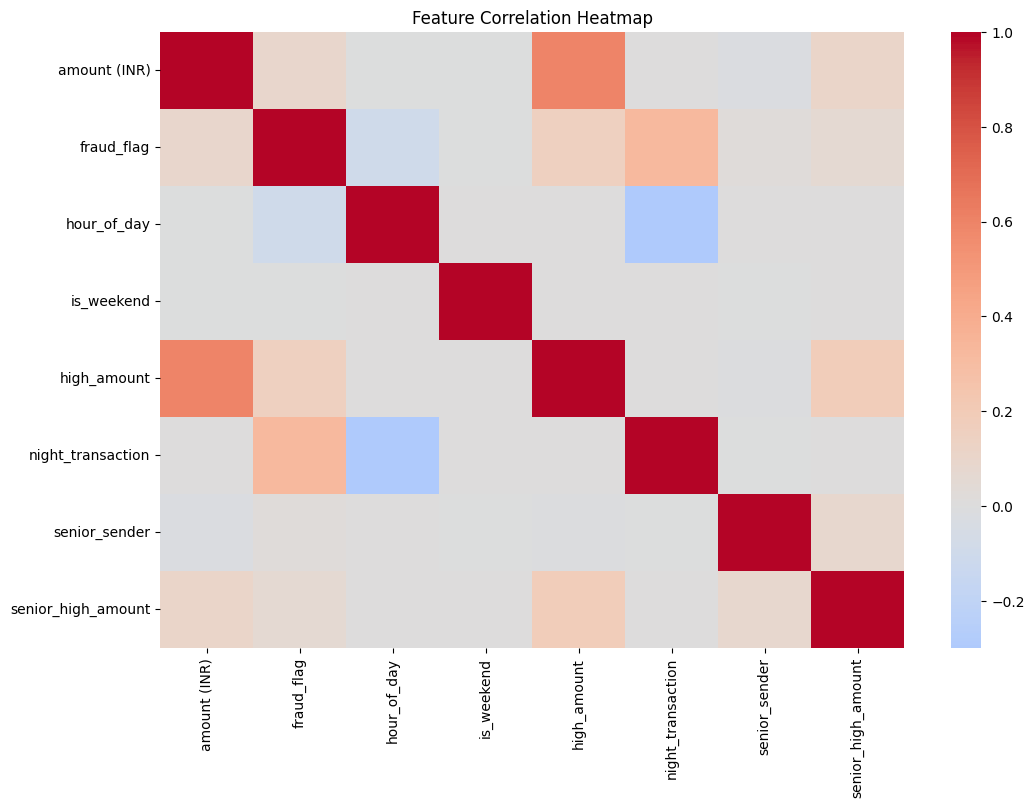

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = df.select_dtypes(include=['int64','float64'])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

In [ ]:
target = "fraud_flag"

corr_target = numeric_df.corr()[target].abs().sort_values(ascending=False)

print(corr_target.head(15))

fraud_flag            1.000000
night_transaction     0.324661
high_amount           0.149004
hour_of_day           0.097207
amount (INR)          0.096395
senior_high_amount    0.062377
senior_sender         0.016816
is_weekend            0.002910
Name: fraud_flag, dtype: float64


In [ ]:
categorical_cols = df.select_dtypes(include="object").columns
categorical_cols = categorical_cols.drop("transaction_notes")
print(categorical_cols)

Index(['transaction id', 'transaction type', 'merchant_category',
       'transaction_status', 'sender_age_group', 'receiver_age_group',
       'sender_state', 'sender_bank', 'receiver_bank', 'device_type',
       'network_type', 'day_of_week'],
      dtype='object')


In [ ]:
df["amount_zscore"] = (df["amount (INR)"] - df["amount (INR)"].mean()) / df["amount (INR)"].std()

In [ ]:
df["night_high_txn"] = df["night_transaction"] * df["high_amount"]

In [ ]:
df["late_night"] = ((df["hour_of_day"] >= 23) | (df["hour_of_day"] <= 4)).astype(int)

In [ ]:
df["bank_risk"] = df.groupby("receiver_bank")["fraud_flag"].transform("mean")
df["network_risk"] = df.groupby("network_type")["fraud_flag"].transform("mean")
df["amount_per_hour"] = df["amount (INR)"] / (df["txn_hour"] + 1)

In [ ]:
df['is_p2p'] = (df['transaction type'] == 'P2P').astype(int)

In [ ]:
df['is_senior'] = (df['sender_age_group'] == '56+').astype(int)

df['senior_high_amount'] = (
    (df['sender_age_group'] == '56+') & (df['amount (INR)'] > 5000)
).astype(int)

In [ ]:
df['is_odd_hour'] = (
    (df['hour_of_day'] >= 23) | (df['hour_of_day'] <= 5)).astype(int)

In [ ]:
df['large_p2p_transfer'] = (
    (df['transaction type'] == 'P2P') & (df['amount (INR)'] > 9000)).astype(int)

In [ ]:
df['p2p_odd_hour'] = (
    (df['transaction type'] == 'P2P') &
    ((df['hour_of_day'] >= 23) | (df['hour_of_day'] <= 5))).astype(int)

In [ ]:
df['senior_odd_hour'] = (
    (df['sender_age_group'] == '56+') &
    ((df['hour_of_day'] >= 23) | (df['hour_of_day'] <= 5))).astype(int)

In [ ]:
df.columns

Index(['transaction id', 'timestamp', 'transaction type', 'merchant_category',
       'amount (INR)', 'transaction_status', 'sender_age_group',
       'receiver_age_group', 'sender_state', 'sender_bank', 'receiver_bank',
       'device_type', 'network_type', 'fraud_flag', 'hour_of_day',
       'day_of_week', 'is_weekend', 'transaction_notes', 'txn_hour', 'txn_day',
       'txn_month', 'high_amount', 'night_transaction', 'senior_sender',
       'senior_high_amount', 'amount_zscore', 'night_high_txn', 'late_night',
       'bank_risk', 'network_risk', 'amount_per_hour', 'is_p2p', 'is_senior',
       'is_odd_hour', 'large_p2p_transfer', 'p2p_odd_hour', 'senior_odd_hour'],
      dtype='object')

In [ ]:
df_for_llm=df.copy()

## 3.1 Data Encoding

In [ ]:
le_dict = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le

In [ ]:
df.columns

Index(['transaction id', 'timestamp', 'transaction type', 'merchant_category',
       'amount (INR)', 'transaction_status', 'sender_age_group',
       'receiver_age_group', 'sender_state', 'sender_bank', 'receiver_bank',
       'device_type', 'network_type', 'fraud_flag', 'hour_of_day',
       'day_of_week', 'is_weekend', 'transaction_notes', 'txn_hour', 'txn_day',
       'txn_month', 'high_amount', 'night_transaction', 'senior_sender',
       'senior_high_amount', 'amount_zscore', 'night_high_txn', 'late_night',
       'bank_risk', 'network_risk', 'amount_per_hour', 'is_p2p', 'is_senior',
       'is_odd_hour', 'large_p2p_transfer', 'p2p_odd_hour', 'senior_odd_hour'],
      dtype='object')

In [ ]:
df_new = df.drop(columns=["transaction_notes"])

## 4. Feature Selection and Data Cleaning

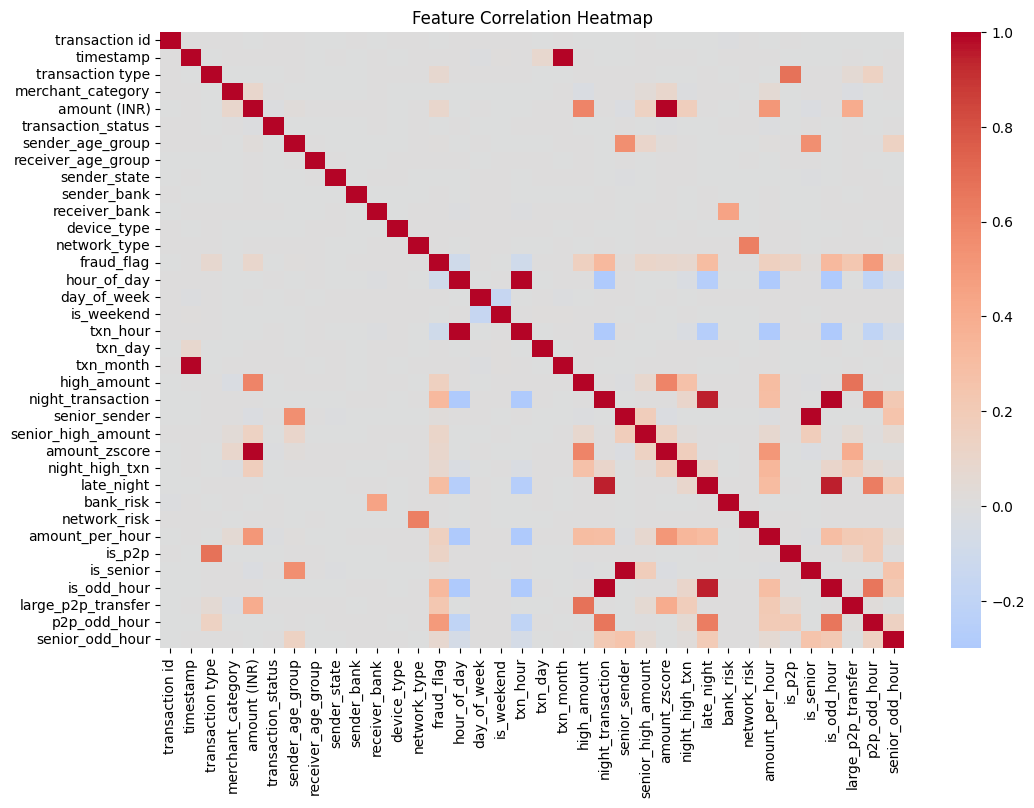

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df_new.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

In [ ]:
corr = df_new.corr()["fraud_flag"].abs().sort_values(ascending=False)
print(corr)

fraud_flag            1.000000
p2p_odd_hour          0.493467
is_odd_hour           0.324661
night_transaction     0.324661
late_night            0.304431
large_p2p_transfer    0.231652
high_amount           0.149004
amount_per_hour       0.148191
is_p2p                0.117847
senior_high_amount    0.105958
txn_hour              0.097207
hour_of_day           0.097207
amount_zscore         0.096395
amount (INR)          0.096395
transaction type      0.079740
senior_odd_hour       0.074597
night_high_txn        0.071700
is_senior             0.016816
senior_sender         0.016816
sender_age_group      0.012829
bank_risk             0.008079
network_risk          0.006405
network_type          0.003967
receiver_bank         0.003640
is_weekend            0.002910
txn_day               0.002613
day_of_week           0.002542
txn_month             0.002253
timestamp             0.002249
sender_state          0.002116
receiver_age_group    0.001970
merchant_category     0.001413
device_t

In [ ]:
df_model = df.drop(columns=["late_night","transaction_notes","txn_hour","amount (INR)","timestamp","transaction id"])

## 5. Model Training Preparation (Train/Test Split & SMOTE)

In [ ]:
X = df_model.drop(columns=["fraud_flag"])
y = df_model["fraud_flag"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [ ]:
print(X_train.shape, X_test.shape)

(200000, 30) (50000, 30)


In [ ]:
import pandas as pd

X_train_df = pd.DataFrame(X_train)
X_test_df = pd.DataFrame(X_test)

y_train_df = pd.DataFrame(y_train, columns=["fraud_flag"])
y_test_df = pd.DataFrame(y_test, columns=["fraud_flag"])

train_df = pd.concat([X_train_df, y_train_df], axis=1)
test_df = pd.concat([X_test_df, y_test_df], axis=1)

train_df.to_csv("train_data.csv", index=False)
test_df.to_csv("test_data.csv", index=False)

print("Saved Successfully")
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Saved Successfully
Train shape: (200000, 31)
Test shape: (50000, 31)


In [ ]:
sm = SMOTE(sampling_strategy=0.3, random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

In [ ]:
print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_res.value_counts())

Before SMOTE:
fraud_flag
0    195994
1      4006
Name: count, dtype: int64

After SMOTE:
fraud_flag
0    195994
1     58798
Name: count, dtype: int64


In [ ]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

## 6. ML Model Selection, Training and Evaluation

In [ ]:
!pip install catboost

In [ ]:
import pandas as pd
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.ensemble import RandomForestClassifier, VotingClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

xgb = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

lgb = LGBMClassifier(
    n_estimators=400,
    learning_rate=0.05,
    random_state=42
)

cat = CatBoostClassifier(
    iterations=400,
    learning_rate=0.05,
    depth=6,
    verbose=0,
    random_state=42
)

models = {
    "RandomForest": rf,
    "XGBoost": xgb,
    "LightGBM": lgb,
    "CatBoost": cat
}

results = []

# Train models

for name, model in models.items():

    print("\n====================")
    print(name)
    print("====================")

    model.fit(X_train_res, y_train_res)

    y_prob = model.predict_proba(X_test)[:,1]
    y_pred = model.predict(X_test)

    roc = roc_auc_score(y_test, y_prob)

    print("ROC-AUC:", roc)
    print(classification_report(y_test, y_pred))

    results.append((name, roc))

# Ensemble Model

ensemble = VotingClassifier(
    estimators=[
        ("rf", rf),
        ("xgb", xgb),
        ("lgb", lgb),
        ("cat", cat)
    ],
    voting="soft"
)

print("\n====================")
print("Ensemble Model")
print("====================")

ensemble.fit(X_train_res, y_train_res)

y_prob = ensemble.predict_proba(X_test)[:,1]
y_pred = ensemble.predict(X_test)

roc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", roc)
print(classification_report(y_test, y_pred))

results.append(("Ensemble", roc))

results_df = pd.DataFrame(results, columns=["Model","ROC-AUC"])
print("\nModel Comparison:")
print(results_df.sort_values("ROC-AUC", ascending=False))


RandomForest
ROC-AUC: 0.8696460908950702
              precision    recall  f1-score   support

           0       0.99      0.98      0.99     48998
           1       0.41      0.69      0.51      1002

    accuracy                           0.97     50000
   macro avg       0.70      0.83      0.75     50000
weighted avg       0.98      0.97      0.98     50000


XGBoost
ROC-AUC: 0.8705979913311056
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     48998
           1       0.43      0.38      0.40      1002

    accuracy                           0.98     50000
   macro avg       0.71      0.69      0.70     50000
weighted avg       0.98      0.98      0.98     50000


LightGBM
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 58798, number of negative: 195994
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.042859 seconds.
Y

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, roc_auc_score

results = []

for name, model in models.items():

    print("\n====================")
    print(name)
    print("====================")

    model.fit(X_train_res, y_train_res)

    y_prob = model.predict_proba(X_test)[:,1]
    y_pred = model.predict(X_test)

    roc = roc_auc_score(y_test, y_prob)

    report = classification_report(
        y_test,
        y_pred,
        output_dict=True
    )

    f1 = report["1"]["f1-score"]
    precision = report["1"]["precision"]
    recall = report["1"]["recall"]

    print("ROC-AUC:", roc)
    print(classification_report(y_test, y_pred))

    results.append({
        "Model": name,
        "ROC-AUC": roc,
        "F1-score": f1,
        "Precision": precision,
        "Recall": recall
    })

# Ensemble

ensemble.fit(X_train_res, y_train_res)

y_prob = ensemble.predict_proba(X_test)[:,1]
y_pred = ensemble.predict(X_test)

roc = roc_auc_score(y_test, y_prob)

report = classification_report(
    y_test,
    y_pred,
    output_dict=True
)

results.append({
    "Model": "Ensemble",
    "ROC-AUC": roc,
    "F1-score": report["1"]["f1-score"],
    "Precision": report["1"]["precision"],
    "Recall": report["1"]["recall"]
})

results_df = pd.DataFrame(results)

print("\nModel Comparison:")
print(results_df.sort_values("ROC-AUC", ascending=False))


RandomForest
ROC-AUC: 0.8696460908950702
              precision    recall  f1-score   support

           0       0.99      0.98      0.99     48998
           1       0.41      0.69      0.51      1002

    accuracy                           0.97     50000
   macro avg       0.70      0.83      0.75     50000
weighted avg       0.98      0.97      0.98     50000


XGBoost
ROC-AUC: 0.8705979913311056
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     48998
           1       0.43      0.38      0.40      1002

    accuracy                           0.98     50000
   macro avg       0.71      0.69      0.70     50000
weighted avg       0.98      0.98      0.98     50000


LightGBM
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 58798, number of negative: 195994
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.063439 seconds.
Y

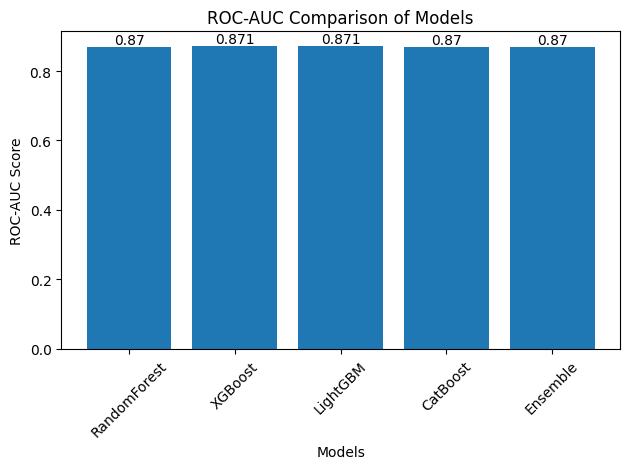

In [ ]:
plt.figure()

plt.bar(
    results_df["Model"],
    results_df["ROC-AUC"]
)

plt.title("ROC-AUC Comparison of Models")

plt.xlabel("Models")
plt.ylabel("ROC-AUC Score")

plt.xticks(rotation=45)

for i, v in enumerate(results_df["ROC-AUC"]):
    plt.text(i, v, round(v, 3), ha="center", va="bottom")

plt.tight_layout()

plt.show()

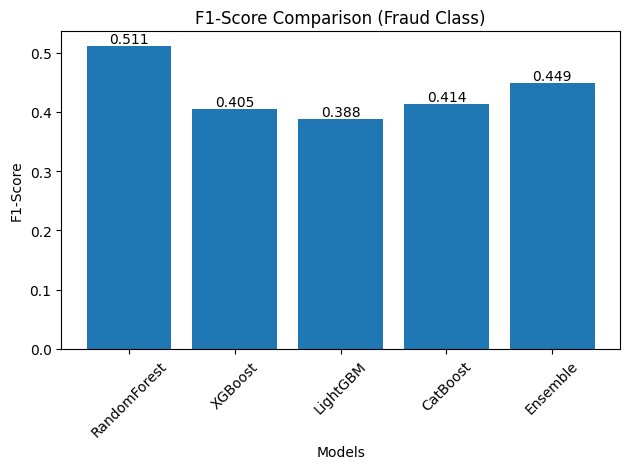

In [ ]:
plt.figure()

plt.bar(
    results_df["Model"],
    results_df["F1-score"]
)

plt.title("F1-Score Comparison (Fraud Class)")

plt.xlabel("Models")
plt.ylabel("F1-Score")

plt.xticks(rotation=45)

for i, v in enumerate(results_df["F1-score"]):
    plt.text(i, v, round(v, 3), ha="center", va="bottom")

plt.tight_layout()

plt.show()

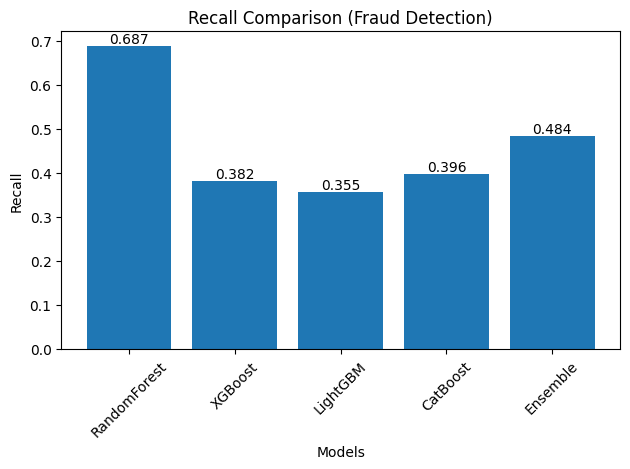

In [ ]:
plt.figure()

plt.bar(
    results_df["Model"],
    results_df["Recall"]
)

plt.title("Recall Comparison (Fraud Detection)")

plt.xlabel("Models")
plt.ylabel("Recall")

plt.xticks(rotation=45)

for i, v in enumerate(results_df["Recall"]):
    plt.text(i, v, round(v, 3), ha="center", va="bottom")

plt.tight_layout()

plt.show()

## 7. Model Optimization (Hyperparameter Tuning)

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [200, 300],
    "max_depth": [10, 12],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt"]
}

grid = GridSearchCV(
    RandomForestClassifier(
        class_weight="balanced",
        random_state=42
    ),
    param_grid,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

grid.fit(X_train_res, y_train_res)

best_rf = grid.best_estimator_

print(grid.best_params_)

{'max_depth': 12, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 200}


In [ ]:
# from sklearn.model_selection import RandomizedSearchCV

# param_dist = {
#     "n_estimators": [200, 300],
#     "max_depth": [10, 12],
#     "min_samples_leaf": [2, 4],
#     "max_features": ["sqrt"]
# }

# random_search = RandomizedSearchCV(
#     RandomForestClassifier(
#         class_weight="balanced",
#         random_state=42,
#         n_jobs=-1
#     ),
#     param_distributions=param_dist,
#     n_iter=10,
#     cv=3,
#     scoring="f1",
#     n_jobs=-1,
#     random_state=42
# )
# random_search.fit(X_train_res, y_train_res)
# best_rf = random_search.best_estimator_
# print(random_search.best_params_)

## 8. Feature Importance

In [ ]:
import pandas as pd

importance = best_rf.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importance
}).sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(20))

               Feature  Importance
28        p2p_odd_hour    0.156761
16   night_transaction    0.125638
26         is_odd_hour    0.112818
22        network_risk    0.100696
10         hour_of_day    0.086812
23     amount_per_hour    0.063789
9         network_type    0.043777
21           bank_risk    0.043386
24              is_p2p    0.040183
19       amount_zscore    0.039630
0     transaction type    0.038665
12          is_weekend    0.020578
11         day_of_week    0.019581
27  large_p2p_transfer    0.019382
15         high_amount    0.018402
8          device_type    0.017229
7        receiver_bank    0.011495
6          sender_bank    0.007514
1    merchant_category    0.006220
5         sender_state    0.005979


## 9. Optimized RF Model Evaluation

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_final = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

rf_final.fit(X_train_res, y_train_res)

RandomForestClassifier(max_depth=12, min_samples_leaf=2, min_samples_split=5,
                       n_estimators=200, n_jobs=-1, random_state=42)

In [ ]:
y_pred = rf_final.predict(X_test)
y_prob = rf_final.predict_proba(X_test)[:,1]

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99     48998
           1       0.41      0.69      0.51      1002

    accuracy                           0.97     50000
   macro avg       0.70      0.83      0.75     50000
weighted avg       0.98      0.97      0.98     50000



In [ ]:
from sklearn.metrics import roc_auc_score

roc = roc_auc_score(y_test, y_prob)
print("ROC AUC Score:", roc)

ROC AUC Score: 0.8698514029535118


In [ ]:
from sklearn.metrics import average_precision_score

pr_auc = average_precision_score(y_test, y_prob)
print("PR AUC:", pr_auc)

PR AUC: 0.32604894167574733


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[47996  1002]
 [  314   688]]


In [ ]:
import joblib
import os

model_path = 'models/rf_fraud_model.pkl'
os.makedirs('models', exist_ok=True)

joblib.dump(rf_final, model_path)
print(f"Model saved successfully to {model_path}")

Model saved successfully to models/rf_fraud_model.pkl


Adding the results back to dataset

In [ ]:
train_prob = rf_final.predict_proba(X_train_res)[:,1]
train_pred = (train_prob >= 0.5).astype(int)

test_prob = rf_final.predict_proba(X_test)[:,1]
test_pred = (test_prob >= 0.5).astype(int)

In [ ]:
# Train results dataframe
train_results_df = pd.DataFrame({
    "y_true": y_train_res,
    "y_prob": train_prob,
    "y_pred": train_pred
})

# Test results dataframe
test_results_df = pd.DataFrame({
    "y_true": y_test,
    "y_prob": test_prob,
    "y_pred": test_pred
})

In [ ]:
# Add predictions to training dataframe
df_train_results = X_train_res.copy()

df_train_results["actual"] = y_train_res
df_train_results["predicted"] = train_pred
df_train_results["probability"] = train_prob


# Add predictions to test dataframe
df_test_results = X_test.copy()

df_test_results["actual"] = y_test
df_test_results["predicted"] = test_pred
df_test_results["probability"] = test_prob

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

print("TRAIN RESULTS")
print(classification_report(y_train_res, train_pred))

train_roc = roc_auc_score(y_train_res, train_prob)
print("Train ROC-AUC:", train_roc)


print("\nTEST RESULTS")
print(classification_report(y_test, test_pred))

test_roc = roc_auc_score(y_test, test_prob)
print("Test ROC-AUC:", test_roc)

TRAIN RESULTS
              precision    recall  f1-score   support

           0       0.95      0.98      0.97    195994
           1       0.94      0.83      0.88     58798

    accuracy                           0.95    254792
   macro avg       0.94      0.91      0.92    254792
weighted avg       0.95      0.95      0.95    254792

Train ROC-AUC: 0.9859564470125519

TEST RESULTS
              precision    recall  f1-score   support

           0       0.99      0.98      0.99     48998
           1       0.41      0.69      0.51      1002

    accuracy                           0.97     50000
   macro avg       0.70      0.83      0.75     50000
weighted avg       0.98      0.97      0.98     50000

Test ROC-AUC: 0.8698514029535118


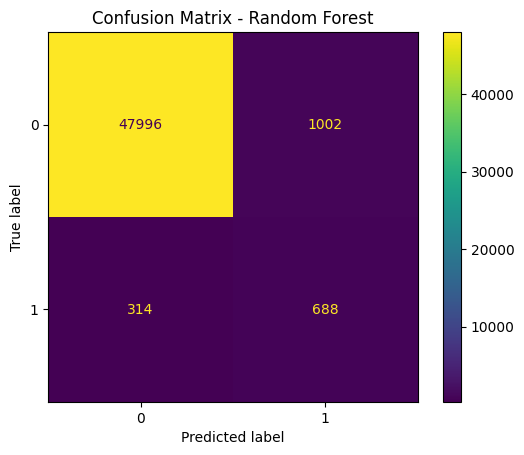

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_pred
)

plt.title("Confusion Matrix - Random Forest")

plt.show()

## **11.Claibrated Classifier**

In [ ]:
from sklearn.calibration import CalibratedClassifierCV

calibrated_rf = CalibratedClassifierCV(
    estimator=rf_final,
    method="isotonic",
    cv=3
)

calibrated_rf.fit(
    X_train_res,
    y_train_res
)

test_prob_calibrated = calibrated_rf.predict_proba(
    X_test
)[:,1]

test_pred_calibrated = (
    test_prob_calibrated >= 0.40
).astype(int)

In [ ]:
import pickle

with open("random_forest_cal.pkl", "wb") as f:
    pickle.dump(calibrated_rf, f)

In [ ]:
df_test_results["probability_calibrated"] = test_prob_calibrated

df_test_results["risk_bucket_calibrated"] = df_test_results[
    "probability_calibrated"
].apply(assign_risk)

In [ ]:
# Train calibrated probabilities
train_prob_calibrated = calibrated_rf.predict_proba(
    X_train_res
)[:, 1]

# Test calibrated probabilities
test_prob_calibrated = calibrated_rf.predict_proba(
    X_test
)[:, 1]


# Add to existing dataframes
df_train_results["prob_rf_calibrated"] = train_prob_calibrated
df_test_results["prob_rf_calibrated"] = test_prob_calibrated

In [ ]:
best_threshold_calibrated = 0.40

df_train_results["pred_rf_calibrated"] = (
    df_train_results["prob_rf_calibrated"]
    >= best_threshold_calibrated
).astype(int)


df_test_results["pred_rf_calibrated"] = (
    df_test_results["prob_rf_calibrated"]
    >= best_threshold_calibrated
).astype(int)

## **13.Text data processing**

In [ ]:
import re

def clean_text(text):

    if pd.isna(text):
        return ""

    text = str(text).lower()

    text = re.sub(
        r"[^a-z\s]",
        " ",
        text
    )

    return text


df["clean_text"] = df[
    "transaction_notes"
].apply(clean_text)

In [ ]:
fraud_texts = df[
    df["fraud_flag"] == 1
]["clean_text"]

nonfraud_texts = df[
    df["fraud_flag"] == 0
]["clean_text"]

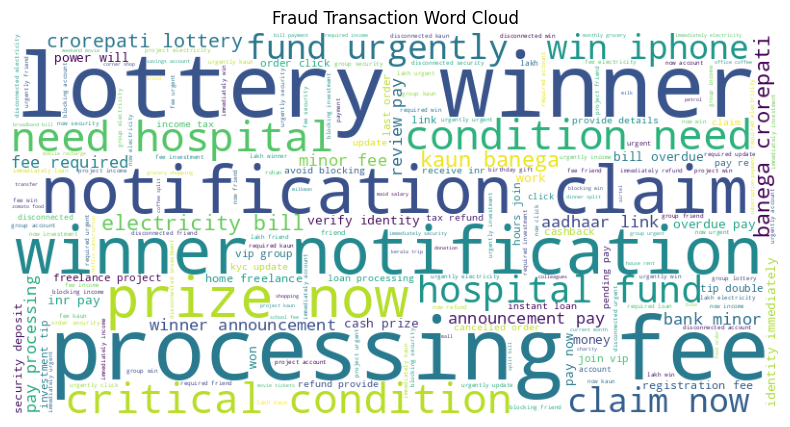

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

fraud_text_combined = " ".join(fraud_texts)

wordcloud_fraud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(fraud_text_combined)

plt.figure(figsize=(12,5))

plt.imshow(wordcloud_fraud)

plt.axis("off")

plt.title(
    "Fraud Transaction Word Cloud"
)

plt.show()

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import torch.nn.functional as F

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model_name = "austinb/fraud_text_detection"

tokenizer = AutoTokenizer.from_pretrained(model_name)

text_model = AutoModelForSequenceClassification.from_pretrained(
    model_name
).to(device)

text_model.eval()

print("Text Model Ready")

config.json:   0%|          | 0.00/725 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Text Model Ready


In [ ]:
def get_text_prediction(text):

    if pd.isna(text):
        text = ""

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    ).to(device)

    with torch.no_grad():

        outputs = text_model(**inputs)

        probs = F.softmax(
            outputs.logits,
            dim=1
        )

    fraud_prob = probs[0][1].item()

    fraud_pred = int(
        fraud_prob >= 0.5
    )

    return fraud_pred, fraud_prob

In [ ]:
df_train_results["transaction_notes"] = df.loc[
    df_train_results.index.intersection(df.index),
    "transaction_notes"
]

df_train_results["transaction_notes"] = df_train_results[
    "transaction_notes"
].fillna(" ")

In [ ]:
df_test_results["transaction_notes"] = df.loc[
    df_test_results.index,
    "transaction_notes"
]

In [ ]:
df_train_results.to_csv("df_train_results.csv", index=False)

print("CSV saved successfully")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

CSV saved successfully


In [ ]:
df_test_results.to_csv("df_test_results.csv", index=False)

print("CSV saved successfully")

CSV saved successfully


In [ ]:
from tqdm import tqdm

df_train_results["clean_text"] = df.loc[
    df_train_results.index.intersection(df.index),
    "clean_text"
].fillna("")

train_text_preds = []
train_text_probs = []

print("\n Running Text Model on TRAIN...\n")

for text in tqdm(
    df_train_results["clean_text"]
):

    pred, prob = get_text_prediction(text)

    train_text_preds.append(pred)

    train_text_probs.append(prob)


df_train_results["text_pred"] = train_text_preds

df_train_results["text_prob"] = train_text_probs

print("Train Text Predictions Done")


 Running Text Model on TRAIN...



100%|██████████| 254792/254792 [18:57<00:00, 223.94it/s]


Train Text Predictions Done


In [ ]:
from tqdm import tqdm
test_text_preds = []
test_text_probs = []

print("\n Running Text Model on TEST...\n")

df_test_results["clean_text"] = df.loc[
    df_test_results.index.intersection(df.index),
    "clean_text"
].fillna("")

for text in tqdm(
    df_test_results["clean_text"]
):

    pred, prob = get_text_prediction(text)

    test_text_preds.append(pred)

    test_text_probs.append(prob)


df_test_results["text_pred"] = test_text_preds

df_test_results["text_prob"] = test_text_probs

print("Test Text Predictions Done")


 Running Text Model on TEST...



100%|██████████| 50000/50000 [03:40<00:00, 226.59it/s]

Test Text Predictions Done


In [ ]:
import numpy as np
from sklearn.metrics import f1_score

thresholds = np.arange(0.01, 0.99, 0.01)

best_threshold = 0.5
best_f1 = 0

for t in thresholds:

    preds = (
        df_train_results["text_prob"]
        >= t
    ).astype(int)

    f1 = f1_score(
        df_train_results["actual"],
        preds
    )

    if f1 > best_f1:

        best_f1 = f1
        best_threshold = t

print("\n Best TEXT Threshold Found")

print("Threshold:", best_threshold)

print("Best F1:", best_f1)


 Best TEXT Threshold Found
Threshold: 0.01
Best F1: 0.23077351450687755


In [ ]:
df_train_results["text_pred"] = (

    df_train_results["text_prob"]
    >= best_threshold

).astype(int)

df_test_results["text_pred"] = (

    df_test_results["text_prob"]
    >= best_threshold

).astype(int)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print("\n TEXT MODEL — TRAIN\n")

print(
    confusion_matrix(
        df_train_results["actual"],
        df_train_results["text_pred"]
    )
)

print(
    classification_report(
        df_train_results["actual"],
        df_train_results["text_pred"]
    )
)


 TEXT MODEL — TRAIN

[[143597  52397]
 [ 44294  14504]]
              precision    recall  f1-score   support

           0       0.76      0.73      0.75    195994
           1       0.22      0.25      0.23     58798

    accuracy                           0.62    254792
   macro avg       0.49      0.49      0.49    254792
weighted avg       0.64      0.62      0.63    254792



In [ ]:
print("\n TEXT MODEL — TEST\n")

print(
    confusion_matrix(
        df_test_results["actual"],
        df_test_results["text_pred"]
    )
)

print(
    classification_report(
        df_test_results["actual"],
        df_test_results["text_pred"]
    )
)


 TEXT MODEL — TEST

[[36499 12499]
 [  163   839]]
              precision    recall  f1-score   support

           0       1.00      0.74      0.85     48998
           1       0.06      0.84      0.12      1002

    accuracy                           0.75     50000
   macro avg       0.53      0.79      0.48     50000
weighted avg       0.98      0.75      0.84     50000



## Comparision with plain RF

In [ ]:
from sklearn.metrics import precision_recall_curve
import numpy as np

# RF probabilities
y_true = df_test_results["actual"]
y_prob_rf = df_test_results["prob_rf_calibrated"]

# Precision-Recall
precision_rf, recall_rf, thresholds_rf = precision_recall_curve(
    y_true,
    y_prob_rf
)

# F1 computation
f1_rf = 2 * (precision_rf * recall_rf) / (
    precision_rf + recall_rf + 1e-9
)

# Best threshold
best_idx_rf = np.argmax(f1_rf)

best_threshold_rf = thresholds_rf[best_idx_rf]

print("Best RF Threshold:", best_threshold_rf)
print("Best RF F1:", f1_rf[best_idx_rf])
print("RF Precision:", precision_rf[best_idx_rf])
print("RF Recall:", recall_rf[best_idx_rf])

Best RF Threshold: 0.809011485789954
Best RF F1: 0.5192511475469066
RF Precision: 0.40185893931109895
RF Recall: 0.7335329341317365


In [ ]:
df_test_results["rf_predicted_optimal"] = (
    df_test_results["prob_rf_calibrated"]
    >= best_threshold_rf
).astype(int)

print("RF predictions created.")

RF predictions created.


In [ ]:
from sklearn.metrics import confusion_matrix

print("RF Confusion Matrix:")

cm_rf = confusion_matrix(
    df_test_results["actual"],
    df_test_results["rf_predicted_optimal"]
)

print(cm_rf)


print("\nHybrid Confusion Matrix:")

cm_hybrid = confusion_matrix(
    df_test_results["actual"],
    df_test_results["hybrid_predicted"]
)

print(cm_hybrid)

RF Confusion Matrix:
[[47904  1094]
 [  267   735]]

Hybrid Confusion Matrix:
[[48322   676]
 [  327   675]]


In [ ]:
from sklearn.metrics import classification_report

print("===== RANDOM FOREST ONLY =====")

print(
    classification_report(
        df_test_results["actual"],
        df_test_results["rf_predicted_optimal"]
    )
)


print("\n===== HYBRID MODEL =====")

print(
    classification_report(
        df_test_results["actual"],
        df_test_results["hybrid_predicted"]
    )
)

===== RANDOM FOREST ONLY =====
              precision    recall  f1-score   support

           0       0.99      0.98      0.99     48998
           1       0.40      0.73      0.52      1002

    accuracy                           0.97     50000
   macro avg       0.70      0.86      0.75     50000
weighted avg       0.98      0.97      0.98     50000


===== HYBRID MODEL =====
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     48998
           1       0.50      0.67      0.57      1002

    accuracy                           0.98     50000
   macro avg       0.75      0.83      0.78     50000
weighted avg       0.98      0.98      0.98     50000



## **16.Improved MLP Integration**

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, f1_score
from sklearn.model_selection import train_test_split

from sentence_transformers import SentenceTransformer

In [ ]:
mlp_feature_cols = [
 'transaction type',
 'merchant_category',
 'transaction_status',
 'sender_age_group',
 'receiver_age_group',
 'sender_state',
 'sender_bank',
 'receiver_bank',
 'device_type',
 'network_type',
 'hour_of_day',
 'day_of_week',
 'is_weekend',
 'txn_day',
 'txn_month',
 'high_amount',
 'night_transaction',
 'senior_sender',
 'senior_high_amount',
 'amount_zscore',
 'night_high_txn',
 'bank_risk',
 'network_risk',
 'amount_per_hour',
 'is_p2p',
 'is_senior',
 'is_odd_hour',
 'large_p2p_transfer',
 'p2p_odd_hour',
 'senior_odd_hour'
]

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
print("MLP feature count:", len(mlp_feature_cols))

MLP feature count: 30


In [ ]:
X_train_np = df_train_results[mlp_feature_cols].values
X_test_np  = df_test_results[mlp_feature_cols].values

# Convert to float tensors
X_train_tensor = torch.tensor(
    X_train_np,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test_np,
    dtype=torch.float32
)

print("Train tensor shape:", X_train_tensor.shape)
print("Test tensor shape:", X_test_tensor.shape)

Train tensor shape: torch.Size([254792, 30])
Test tensor shape: torch.Size([50000, 30])


In [ ]:
import numpy as np

X_train_mlp = df_train_results[
    mlp_feature_cols
].values.astype(np.float32)

X_test_mlp = df_test_results[
    mlp_feature_cols
].values.astype(np.float32)

In [ ]:
import torch
import torch.nn as nn

class FraudMLP(nn.Module):

    def __init__(self, input_dim):
        super(FraudMLP, self).__init__()

        self.net = nn.Sequential(

            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
input_dim = len(mlp_feature_cols)

mlp_model = FraudMLP(input_dim)

mlp_model.load_state_dict(
    torch.load(
        "/content/improved_mlp_fraud.pth",
        map_location="cpu"
    )
)
mlp_model.to(device) # Move the model to the correct device
mlp_model.eval()

print("MLP loaded successfully")

MLP loaded successfully


In [ ]:
def predict_mlp_probs(X):

    X_tensor = torch.tensor(
        X,
        dtype=torch.float32
    ).to(device)

    with torch.no_grad():

        logits = mlp_model(X_tensor)

        probs = torch.sigmoid(
            logits
        ).cpu().numpy().flatten()

    return probs

In [ ]:
# TRAIN
df_train_results['mlp_probs'] = predict_mlp_probs(
    X_train_mlp
)

# TEST
df_test_results['mlp_probs'] = predict_mlp_probs(
    X_test_mlp
)

print(" MLP probabilities added")

 MLP probabilities added


In [ ]:
df_test_results.columns

Index(['transaction type', 'merchant_category', 'transaction_status',
       'sender_age_group', 'receiver_age_group', 'sender_state', 'sender_bank',
       'receiver_bank', 'device_type', 'network_type', 'hour_of_day',
       'day_of_week', 'is_weekend', 'txn_day', 'txn_month', 'high_amount',
       'night_transaction', 'senior_sender', 'senior_high_amount',
       'amount_zscore', 'night_high_txn', 'bank_risk', 'network_risk',
       'amount_per_hour', 'is_p2p', 'is_senior', 'is_odd_hour',
       'large_p2p_transfer', 'p2p_odd_hour', 'senior_odd_hour', 'actual',
       'predicted', 'probability', 'risk_bucket', 'probability_calibrated',
       'risk_bucket_calibrated', 'prob_rf_calibrated', 'pred_rf_calibrated',
       'transaction_notes', 'clean_text', 'text_pred', 'text_prob',
       'hybrid_prob_alpha_0.03', 'hybrid_prob_alpha_0.05',
       'hybrid_prob_alpha_0.07', 'hybrid_prob_alpha_0.1',
       'risk_bucket_hybrid_0.03', 'risk_bucket_hybrid_0.05',
       'risk_bucket_hybrid_0.0

In [ ]:
mlp_model.eval()

with torch.no_grad():

    # TRAIN
    train_probs = mlp_model(
        X_train_tensor.to(device)
    ).squeeze()

    train_probs = torch.sigmoid(
        train_probs
    ).cpu().numpy()

    # TEST
    test_probs = mlp_model(
        X_test_tensor.to(device)
    ).squeeze()

    test_probs = torch.sigmoid(
        test_probs
    ).cpu().numpy()

print("MLP predictions generated.")

MLP predictions generated.


In [ ]:
from sklearn.metrics import classification_report

threshold = 0.2

mlp_test_pred = (
    test_probs >= threshold
).astype(int)

print("\nMLP TEST RESULTS")

print(
    classification_report(
        y_test,
        mlp_test_pred,
        digits=4
    )
)


MLP TEST RESULTS
              precision    recall  f1-score   support

           0     0.9800    0.9990    0.9894     48998
           1     0.0204    0.0010    0.0019      1002

    accuracy                         0.9790     50000
   macro avg     0.5002    0.5000    0.4957     50000
weighted avg     0.9607    0.9790    0.9696     50000



In [ ]:
print("Min prob:", test_probs.min())
print("Max prob:", test_probs.max())
print("Mean prob:", test_probs.mean())

Min prob: 0.0
Max prob: 0.7611983
Mean prob: 0.0014238432


In [ ]:
from sklearn.metrics import classification_report, f1_score

thresholds = [0.5, 0.3, 0.2, 0.1, 0.05, 0.02]

for t in thresholds:

    preds = (test_probs >= t).astype(int)

    f1 = f1_score(y_test, preds)

    print(f"\nThreshold: {t}")
    print("Fraud F1:", f1)

    print(
        classification_report(
            y_test,
            preds,
            digits=4
        )
    )


Threshold: 0.5
Fraud F1: 0.0
              precision    recall  f1-score   support

           0     0.9800    0.9999    0.9898     48998
           1     0.0000    0.0000    0.0000      1002

    accuracy                         0.9798     50000
   macro avg     0.4900    0.4999    0.4949     50000
weighted avg     0.9603    0.9798    0.9700     50000


Threshold: 0.3
Fraud F1: 0.0
              precision    recall  f1-score   support

           0     0.9800    0.9997    0.9897     48998
           1     0.0000    0.0000    0.0000      1002

    accuracy                         0.9796     50000
   macro avg     0.4900    0.4998    0.4949     50000
weighted avg     0.9603    0.9796    0.9699     50000


Threshold: 0.2
Fraud F1: 0.0019029495718363464
              precision    recall  f1-score   support

           0     0.9800    0.9990    0.9894     48998
           1     0.0204    0.0010    0.0019      1002

    accuracy                         0.9790     50000
   macro avg     0.5

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, f1_score

# True labels
y_true = df_test_results["actual"]

# Probabilities
rf_probs  = df_test_results["prob_rf_calibrated"]
mlp_probs = df_test_results["mlp_probs"]

# Try different ratios
ratios = [
    (1.0, 0.0),  # RF only
    (0.9, 0.1),
    (0.8, 0.2),
    (0.7, 0.3),
    (0.6, 0.4),
    (0.5, 0.5),
    (0.4, 0.6),
    (0.3, 0.7),
    (0.2, 0.8),
    (0.1, 0.9),
    (0.0, 1.0)
]

threshold = 0.5

results = []

for rf_w, mlp_w in ratios:

    combined_probs = (
        rf_w * rf_probs +
        mlp_w * mlp_probs
    )

    preds = (
        combined_probs >= threshold
    ).astype(int)

    f1 = f1_score(y_true, preds)

    print("\n==============================")
    print(f"RF:{rf_w}  MLP:{mlp_w}")

    print(
        classification_report(
            y_true,
            preds,
            digits=4
        )
    )

    results.append(
        (rf_w, mlp_w, f1)
    )


RF:1.0  MLP:0.0
              precision    recall  f1-score   support

           0     0.9950    0.9743    0.9845     48998
           1     0.3773    0.7625    0.5048      1002

    accuracy                         0.9700     50000
   macro avg     0.6862    0.8684    0.7447     50000
weighted avg     0.9827    0.9700    0.9749     50000


RF:0.9  MLP:0.1
              precision    recall  f1-score   support

           0     0.9950    0.9747    0.9847     48998
           1     0.3805    0.7615    0.5075      1002

    accuracy                         0.9704     50000
   macro avg     0.6878    0.8681    0.7461     50000
weighted avg     0.9827    0.9704    0.9752     50000


RF:0.8  MLP:0.2
              precision    recall  f1-score   support

           0     0.9949    0.9752    0.9850     48998
           1     0.3842    0.7565    0.5096      1002

    accuracy                         0.9708     50000
   macro avg     0.6896    0.8658    0.7473     50000
weighted avg     0.9827

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## **Final results combination approches**

**APPROACH-1: meta learner**

In [ ]:
meta_features = [
    "prob_rf_calibrated",       # RF calibrated
    "mlp_probs",                # MLP
    "text_prob"                 # TEXT
]

In [ ]:
X_train_meta = df_train_results[
    meta_features
]

y_train_meta = df_train_results[
    "actual"
]


X_test_meta = df_test_results[
    meta_features
]

y_test_meta = df_test_results[
    "actual"
]

In [ ]:
from sklearn.linear_model import LogisticRegression

meta_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced"
)

meta_model.fit(
    X_train_meta,
    y_train_meta
)

print("Stacking Model Trained")

Stacking Model Trained


In [ ]:
weights = pd.DataFrame({

    "Model": meta_features,

    "Weight": meta_model.coef_[0]

})

print("\n Meta-Learner Weights:\n")

print(
    weights.sort_values(
        by="Weight",
        ascending=False
    )
)


 Meta-Learner Weights:

                Model    Weight
0  prob_rf_calibrated  7.905757
1           mlp_probs  0.017424
2           text_prob -0.096367


In [ ]:
train_probs = meta_model.predict_proba(
    X_train_meta
)[:, 1]

df_train_results["stack_prob"] = train_probs

df_train_results["stack_pred"] = (
    train_probs >= 0.5
).astype(int)

In [ ]:
test_probs = meta_model.predict_proba(
    X_test_meta
)[:, 1]

df_test_results["stack_prob"] = test_probs

df_test_results["stack_pred"] = (
    test_probs >= 0.5
).astype(int)

In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print("\n STACKING TEST RESULTS\n")

print(
    confusion_matrix(
        y_test_meta,
        df_test_results["stack_pred"]
    )
)

print(
    classification_report(
        y_test_meta,
        df_test_results["stack_pred"],
        digits=4
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test_meta,
        df_test_results["stack_prob"]
    )
)


 STACKING TEST RESULTS

[[47674  1324]
 [  238   764]]
              precision    recall  f1-score   support

           0     0.9950    0.9730    0.9839     48998
           1     0.3659    0.7625    0.4945      1002

    accuracy                         0.9688     50000
   macro avg     0.6805    0.8677    0.7392     50000
weighted avg     0.9824    0.9688    0.9741     50000

ROC-AUC: 0.8297939510179201


In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    precision_recall_curve,
    auc,
    roc_curve
)
precision, recall, pr_thresholds = precision_recall_curve(
    y_test_meta,
    df_test_results["stack_prob"]
)

pr_auc = auc(recall, precision)

print("PR-AUC:", pr_auc)

PR-AUC: 0.291904141309341


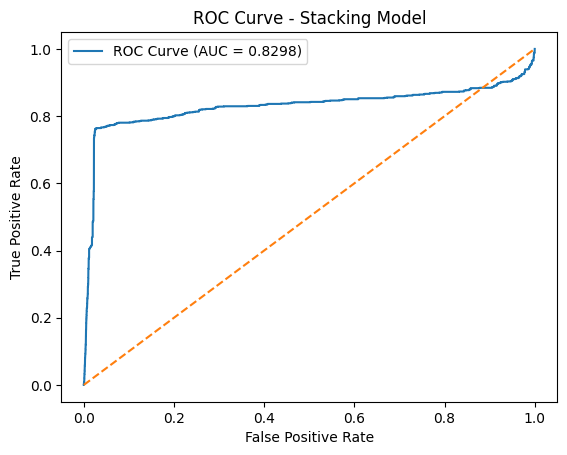

In [ ]:
fpr, tpr, roc_thresholds = roc_curve(
    y_test_meta,
    df_test_results["stack_prob"]
)

# Calculate the ROC AUC score and store it in a variable
auc_value = roc_auc_score(y_test_meta, df_test_results["stack_prob"])

plt.figure()

plt.plot(
    fpr,
    tpr,
    label=f"ROC Curve (AUC = {auc_value:.4f})"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Stacking Model")

plt.legend()

plt.show()

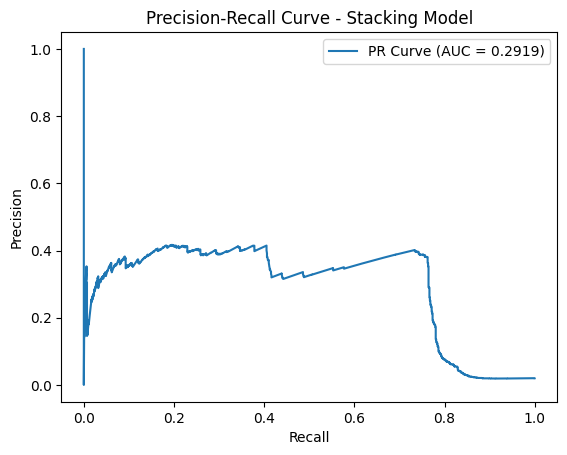

In [ ]:
plt.figure()

plt.plot(
    recall,
    precision,
    label=f"PR Curve (AUC = {pr_auc:.4f})"
)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision-Recall Curve - Stacking Model")

plt.legend()

plt.show()

**APPROACH-2: Weighted Soft Voting**

In [ ]:
w_rf_cal = 0.60
w_mlp = 0.20
w_text = 0.20

In [ ]:
df_test_results["weighted_prob"] = (

      w_rf_cal * df_test_results["prob_rf_calibrated"]

    + w_mlp    * df_test_results["mlp_probs"]

    + w_text   * df_test_results["text_prob"]

)

In [ ]:
from sklearn.metrics import roc_curve
import numpy as np

# Compute ROC Curve

fpr, tpr, thresholds = roc_curve(
    df_test_results["actual"],
    df_test_results["weighted_prob"]
)

# Compute Youden's J

youden_j = tpr - fpr

# Find Best Threshold

best_index = np.argmax(youden_j)

stat_threshold = thresholds[best_index]

print("\n Statistical Threshold (Youden J):")
print(stat_threshold)


 Statistical Threshold (Youden J):
0.1905684761551835


In [ ]:
df_test_results["weighted_pred_stat"] = (

    df_test_results["weighted_prob"]
    >= stat_threshold

).astype(int)

In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print("\n WEIGHTED VOTING — STATISTICAL THRESHOLD\n")

print(
    confusion_matrix(
        df_test_results["actual"],
        df_test_results["weighted_pred_stat"]
    )
)

print(
    classification_report(
        df_test_results["actual"],
        df_test_results["weighted_pred_stat"],
        digits=4
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        df_test_results["actual"],
        df_test_results["weighted_prob"]
    )
)


 WEIGHTED VOTING — STATISTICAL THRESHOLD

[[47144  1854]
 [  119   883]]
              precision    recall  f1-score   support

           0     0.9975    0.9622    0.9795     48998
           1     0.3226    0.8812    0.4723      1002

    accuracy                         0.9605     50000
   macro avg     0.6600    0.9217    0.7259     50000
weighted avg     0.9840    0.9605    0.9693     50000

ROC-AUC: 0.9519113737910521


In [ ]:
import numpy as np
from sklearn.metrics import f1_score

best_f1 = 0
best_weights = None

weights = np.arange(0, 1.1, 0.1)

for w_rf in weights:
    for w_mlp in weights:
        for w_text in weights:

            if abs(w_rf + w_mlp + w_text - 1) > 0.01:
                continue

            weighted_prob = (
                  w_rf   * df_test_results["prob_rf_calibrated"]
                + w_mlp  * df_test_results["mlp_probs"]
                + w_text * df_test_results["text_prob"]
            )

            preds = (weighted_prob >= 0.5).astype(int)

            f1 = f1_score(
                df_test_results["actual"],
                preds
            )

            if f1 > best_f1:
                best_f1 = f1
                best_weights = (w_rf, w_mlp, w_text)

print("Best F1:", best_f1)

print("Best Weights (RF, MLP, TEXT):", best_weights)

Best F1: 0.5793167992512869
Best Weights (RF, MLP, TEXT): (np.float64(0.6000000000000001), np.float64(0.2), np.float64(0.2))


In [ ]:
from sklearn.metrics import (
    precision_recall_curve,
    roc_curve,
    auc
)

import matplotlib.pyplot as plt


precision, recall, pr_thresholds = precision_recall_curve(
    df_test_results["actual"],
    df_test_results["weighted_prob"]
)

pr_auc = auc(recall, precision)

print("PR-AUC:", pr_auc)



PR-AUC: 0.6126898223026727


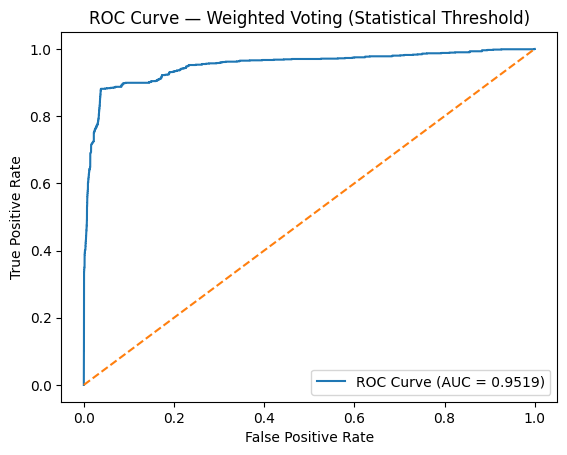

In [ ]:

fpr, tpr, roc_thresholds = roc_curve(
    df_test_results["actual"],
    df_test_results["weighted_prob"]
)

roc_auc = auc(fpr, tpr)

plt.figure()

plt.plot(
    fpr,
    tpr,
    label=f"ROC Curve (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve — Weighted Voting (Statistical Threshold)")

plt.legend()

plt.show()

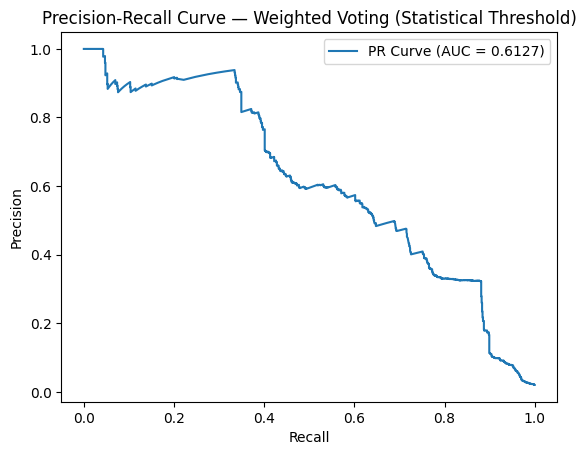

In [ ]:
plt.figure()

plt.plot(
    recall,
    precision,
    label=f"PR Curve (AUC = {pr_auc:.4f})"
)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision-Recall Curve — Weighted Voting (Statistical Threshold)")

plt.legend()

plt.show()

**APPROACH-3: Cascading**

In [ ]:
df_test_results["cascade_prob"] = 0.0
LOW_THRESHOLD = 0.10
HIGH_THRESHOLD = 0.90

In [ ]:
for idx in df_test_results.index:

    # Use CALIBRATED RF
    cal_rf_prob = df_test_results.loc[idx, "prob_rf_calibrated"]

    # Case 1 — Very Safe
    if cal_rf_prob < LOW_THRESHOLD:

        df_test_results.loc[idx, "cascade_prob"] = cal_rf_prob


    # Case 2 — Very Risky
    elif cal_rf_prob > HIGH_THRESHOLD:

        df_test_results.loc[idx, "cascade_prob"] = cal_rf_prob


    # Case 3 — Gray Zone
    else:

        mlp_prob = df_test_results.loc[idx, "mlp_probs"]

        text_prob = df_test_results.loc[idx, "text_prob"]

        # Gray zone fusion
        combined_prob = (

              0.75 * cal_rf_prob
            + 0.20 * mlp_prob
            + 0.05 * text_prob

        )

        df_test_results.loc[idx, "cascade_prob"] = combined_prob

In [ ]:
cascade_threshold = 0.44

df_test_results["cascade_pred"] = (

    df_test_results["cascade_prob"]
    >= cascade_threshold

).astype(int)

In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score
)

print("\n APPROACH 3 — CASCADING RESULTS\n")

print(
    confusion_matrix(
        df_test_results["actual"],
        df_test_results["cascade_pred"]
    )
)

print(
    classification_report(
        df_test_results["actual"],
        df_test_results["cascade_pred"],
        digits=4
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        df_test_results["actual"],
        df_test_results["cascade_prob"]
    )
)


 APPROACH 3 — CASCADING RESULTS

[[47764  1234]
 [  239   763]]
              precision    recall  f1-score   support

           0     0.9950    0.9748    0.9848     48998
           1     0.3821    0.7615    0.5088      1002

    accuracy                         0.9705     50000
   macro avg     0.6885    0.8681    0.7468     50000
weighted avg     0.9827    0.9705    0.9753     50000

ROC-AUC: 0.8725069453728976


In [ ]:
from sklearn.metrics import (
    precision_recall_curve,
    auc
)


precision, recall, pr_thresholds = precision_recall_curve(
    df_test_results["actual"],
    df_test_results["cascade_prob"]
)

pr_auc = auc(recall, precision)

print("PR-AUC:", pr_auc)

PR-AUC: 0.38847240020015494


In [ ]:
gray_zone_count = (

    (df_test_results["prob_rf_calibrated"] >= LOW_THRESHOLD)
    &
    (df_test_results["prob_rf_calibrated"] <= HIGH_THRESHOLD)

).sum()

total = len(df_test_results)

print("\n Cascade Efficiency\n")

print(
    "Gray Zone Samples:",
    gray_zone_count
)

print(
    "Percentage needing extra models:",
    (gray_zone_count / total) * 100
)


 Cascade Efficiency

Gray Zone Samples: 3324
Percentage needing extra models: 6.648


In [ ]:
mean_prob = df_test_results["prob_rf_calibrated"].mean()

std_prob = df_test_results["prob_rf_calibrated"].std()

LOW_THRESHOLD = mean_prob - std_prob

HIGH_THRESHOLD = mean_prob + std_prob

# Ensure bounds are valid

LOW_THRESHOLD = max(0, LOW_THRESHOLD)

HIGH_THRESHOLD = min(1, HIGH_THRESHOLD)

print("\n Improved Statistical Gray Zone\n")

print("Mean:", mean_prob)

print("Std:", std_prob)

print("LOW_THRESHOLD:", LOW_THRESHOLD)

print("HIGH_THRESHOLD:", HIGH_THRESHOLD)


 Improved Statistical Gray Zone

Mean: 0.050852157789548186
Std: 0.1651745951714561
LOW_THRESHOLD: 0
HIGH_THRESHOLD: 0.2160267529610043


In [ ]:
LOW_THRESHOLD = 0
HIGH_THRESHOLD = 0.216

df_test_results["cascade_prob_v3"] = 0.0

gray_count = 0

for idx in df_test_results.index:

    cal_rf_prob = df_test_results.loc[idx, "prob_rf_calibrated"]

    # SAFE ZONE
    if cal_rf_prob < LOW_THRESHOLD:

        df_test_results.loc[idx, "cascade_prob_v3"] = cal_rf_prob

    # HIGH-RISK ZONE
    elif cal_rf_prob > HIGH_THRESHOLD:

        df_test_results.loc[idx, "cascade_prob_v3"] = cal_rf_prob

    # GRAY ZONE
    else:

        gray_count += 1

        mlp_prob = df_test_results.loc[idx, "mlp_probs"]

        text_prob = df_test_results.loc[idx, "text_prob"]

        combined_prob = (

              0.85 * cal_rf_prob
            + 0.10 * mlp_prob
            + 0.05 * text_prob

        )

        df_test_results.loc[idx, "cascade_prob_v3"] = combined_prob

In [ ]:
cascade_threshold = 0.44

df_test_results["cascade_pred_v3"] = (

    df_test_results["cascade_prob_v3"]
    >= cascade_threshold

).astype(int)

In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score
)

print("\n CASCADE V3 RESULTS\n")

print(
    confusion_matrix(
        df_test_results["actual"],
        df_test_results["cascade_pred_v3"]
    )
)

print(
    classification_report(
        df_test_results["actual"],
        df_test_results["cascade_pred_v3"],
        digits=4
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        df_test_results["actual"],
        df_test_results["cascade_prob_v3"]
    )
)


 CASCADE V3 RESULTS

[[47707  1291]
 [  238   764]]
              precision    recall  f1-score   support

           0     0.9950    0.9737    0.9842     48998
           1     0.3718    0.7625    0.4998      1002

    accuracy                         0.9694     50000
   macro avg     0.6834    0.8681    0.7420     50000
weighted avg     0.9825    0.9694    0.9745     50000

ROC-AUC: 0.9341578893724858


In [ ]:
gray_zone_mask = (

    (df_test_results["prob_rf_calibrated"] >= LOW_THRESHOLD)
    &
    (df_test_results["prob_rf_calibrated"] <= HIGH_THRESHOLD)

)

gray_zone_count = gray_zone_mask.sum()

total = len(df_test_results)

print("\n CASCADE V3 EFFICIENCY\n")

print("Gray Zone Samples:", gray_zone_count)

print(
    "Percentage needing extra models:",
    round((gray_zone_count / total) * 100, 3),
    "%"
)


 CASCADE V3 EFFICIENCY

Gray Zone Samples: 47457
Percentage needing extra models: 94.914 %


In [ ]:
LOW_THRESHOLD = np.percentile(
    df_test_results["prob_rf_calibrated"],
    5
)

HIGH_THRESHOLD = np.percentile(
    df_test_results["prob_rf_calibrated"],
    95
)

print("\n📊 Quantile-Based Gray Zone\n")

print("LOW_THRESHOLD:", LOW_THRESHOLD)

print("HIGH_THRESHOLD:", HIGH_THRESHOLD)


📊 Quantile-Based Gray Zone

LOW_THRESHOLD: 0.002325581395348837
HIGH_THRESHOLD: 0.23225706818270667


In [ ]:
df_test_results["cascade_prob_v4"] = 0.0

gray_count = 0

for idx in df_test_results.index:

    cal_rf_prob = df_test_results.loc[idx, "prob_rf_calibrated"]

    # SAFE
    if cal_rf_prob < LOW_THRESHOLD:

        df_test_results.loc[idx, "cascade_prob_v4"] = cal_rf_prob

    # HIGH RISK
    elif cal_rf_prob > HIGH_THRESHOLD:

        df_test_results.loc[idx, "cascade_prob_v4"] = cal_rf_prob

    # GRAY ZONE
    else:

        gray_count += 1

        mlp_prob = df_test_results.loc[idx, "mlp_probs"]

        text_prob = df_test_results.loc[idx, "text_prob"]

        combined_prob = (

              0.85 * cal_rf_prob
            + 0.10 * mlp_prob
            + 0.05 * text_prob

        )

        df_test_results.loc[idx, "cascade_prob_v4"] = combined_prob

In [ ]:
cascade_threshold = 0.44

df_test_results["cascade_pred_v4"] = (

    df_test_results["cascade_prob_v4"]
    >= cascade_threshold

).astype(int)

In [ ]:
gray_zone_mask = (

    (df_test_results["prob_rf_calibrated"] >= LOW_THRESHOLD)
    &
    (df_test_results["prob_rf_calibrated"] <= HIGH_THRESHOLD)

)

gray_zone_count = gray_zone_mask.sum()

total = len(df_test_results)

print("\n CASCADE V4 EFFICIENCY\n")

print("Gray Zone Samples:", gray_zone_count)

print(
    "Percentage needing extra models:",
    round((gray_zone_count / total) * 100, 3),
    "%"
)


 CASCADE V4 EFFICIENCY

Gray Zone Samples: 46415
Percentage needing extra models: 92.83 %


**APPROACH-4: Confidence - Based cascading**

In [ ]:
final_threshold = 0.44

df_test_results["rf_confidence"] = abs(

    df_test_results["prob_rf_calibrated"]
    - final_threshold

)

In [ ]:
CONF_THRESHOLD = np.percentile(
    df_test_results["rf_confidence"],
    10
)

print("Confidence Threshold:", CONF_THRESHOLD)

Confidence Threshold: 0.3928239439260728


In [ ]:
df_test_results["cascade_prob_v5"] = 0.0

gray_count = 0

for idx in df_test_results.index:

    cal_rf_prob = df_test_results.loc[idx, "prob_rf_calibrated"]

    confidence = df_test_results.loc[idx, "rf_confidence"]

    # CONFIDENT → Trust RF
    if confidence > CONF_THRESHOLD:

        df_test_results.loc[idx, "cascade_prob_v5"] = cal_rf_prob

    # UNCERTAIN → Use Extra Models
    else:

        gray_count += 1

        mlp_prob = df_test_results.loc[idx, "mlp_probs"]

        text_prob = df_test_results.loc[idx, "text_prob"]

        combined_prob = (

              0.85 * cal_rf_prob
            + 0.10 * mlp_prob
            + 0.05 * text_prob

        )

        df_test_results.loc[idx, "cascade_prob_v5"] = combined_prob

In [ ]:
cascade_threshold = 0.44

df_test_results["cascade_pred_v5"] = (

    df_test_results["cascade_prob_v5"]
    >= cascade_threshold

).astype(int)

In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score
)

print("\n CASCADE V5 RESULTS\n")

print(
    confusion_matrix(
        df_test_results["actual"],
        df_test_results["cascade_pred_v5"]
    )
)

print(
    classification_report(
        df_test_results["actual"],
        df_test_results["cascade_pred_v5"],
        digits=4
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        df_test_results["actual"],
        df_test_results["cascade_prob_v5"]
    )
)


 CASCADE V5 RESULTS

[[47742  1256]
 [  238   764]]
              precision    recall  f1-score   support

           0     0.9950    0.9744    0.9846     48998
           1     0.3782    0.7625    0.5056      1002

    accuracy                         0.9701     50000
   macro avg     0.6866    0.8684    0.7451     50000
weighted avg     0.9827    0.9701    0.9750     50000

ROC-AUC: 0.8718694086580909


In [ ]:
gray_zone_mask = (

    df_test_results["rf_confidence"]
    <= CONF_THRESHOLD

)

gray_zone_count = gray_zone_mask.sum()

total = len(df_test_results)

print("\n CASCADE V5 EFFICIENCY\n")

print("Gray Zone Samples:", gray_zone_count)

print(
    "Percentage needing extra models:",
    round((gray_zone_count / total) * 100, 3),
    "%"
)


 CASCADE V5 EFFICIENCY

Gray Zone Samples: 5022
Percentage needing extra models: 10.044 %


## **Ablation Study**

In [ ]:
import pandas as pd
import numpy as np

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    roc_auc_score
)

In [ ]:
thresholds = {

    "rf": 0.81,
    "cal_rf": 0.40,
    "mlp": 0.02,
    "text": 0.5,
    "final": 0.19
}

In [ ]:
df_test_results["rf_only"] = df_test_results["probability"]

df_test_results["cal_rf_only"] = df_test_results["prob_rf_calibrated"]

df_test_results["mlp_only"] = df_test_results["mlp_probs"]

df_test_results["text_only"] = df_test_results["text_pred"]

In [ ]:
# RF + MLP

df_test_results["rf_mlp"] = (

    0.7 * df_test_results["prob_rf_calibrated"]
    + 0.3 * df_test_results["mlp_probs"]

)

# RF + Text

df_test_results["rf_text"] = (

    0.8 * df_test_results["prob_rf_calibrated"]
    + 0.2 * df_test_results["text_prob"]

)

# MLP + Text

df_test_results["mlp_text"] = (

    0.6 * df_test_results["mlp_probs"]
    + 0.4 * df_test_results["text_prob"]

)

In [ ]:
df_test_results["payshield_final"] = df_test_results["weighted_prob"]

In [ ]:
def evaluate_model(name, probs, threshold):

    y_true = df_test_results["actual"]

    preds = (probs >= threshold).astype(int)

    precision = precision_score(
        y_true,
        preds,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        preds
    )

    f1 = f1_score(
        y_true,
        preds
    )

    accuracy = accuracy_score(
        y_true,
        preds
    )

    auc = roc_auc_score(
        y_true,
        probs
    )

    return {

        "Model": name,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "Accuracy": accuracy,
        "ROC-AUC": auc

    }

In [ ]:
results = []

results.append(
    evaluate_model(
        "RF Only",
        df_test_results["rf_only"],
        thresholds["rf"]
    )
)

results.append(
    evaluate_model(
        "Calibrated RF",
        df_test_results["cal_rf_only"],
        thresholds["cal_rf"]
    )
)

results.append(
    evaluate_model(
        "MLP Only",
        df_test_results["mlp_only"],
        thresholds["mlp"]
    )
)

results.append(
    evaluate_model(
        "Text Only",
        df_test_results["text_only"],
        thresholds["text"]
    )
)

results.append(
    evaluate_model(
        "RF + MLP",
        df_test_results["rf_mlp"],
        thresholds["final"]
    )
)

results.append(
    evaluate_model(
        "RF + Text",
        df_test_results["rf_text"],
        thresholds["final"]
    )
)

results.append(
    evaluate_model(
        "MLP + Text",
        df_test_results["mlp_text"],
        thresholds["final"]
    )
)

results.append(
    evaluate_model(
        "PayShield Final",
        df_test_results["payshield_final"],
        thresholds["final"]
    )
)

In [ ]:
desired_order = [

    "PayShield Final",
    "RF + MLP",
    "RF + Text",
    "Calibrated RF",
    "RF Only",
    "Text Only",
    "MLP Only",
    "MLP + Text"

]

ablation_df = pd.DataFrame(results)

ablation_df["Model"] = pd.Categorical(
    ablation_df["Model"],
    categories=desired_order,
    ordered=True
)

ablation_df = ablation_df.sort_values("Model")

ablation_df.reset_index(drop=True, inplace=True)

ablation_df

,Model,Precision,Recall,F1 Score,Accuracy,ROC-AUC
0,PayShield Final,0.322263,0.881238,0.471940,0.96048,0.951911
1,RF + MLP,0.321849,0.764471,0.452986,0.96300,0.869199
2,RF + Text,0.291708,0.881238,0.438322,0.95474,0.950313
3,Calibrated RF,0.365900,0.762475,0.494498,0.96876,0.869797
4,RF Only,0.434363,0.224551,0.296053,0.97860,0.869851
5,Text Only,0.062903,0.837325,0.117015,0.74676,0.791117
6,MLP Only,0.019635,0.013972,0.016327,0.96626,0.341850
7,MLP + Text,0.091740,0.520958,0.156007,0.88704,0.826162


In [ ]:
ablation_df.to_csv(
    "payshield_ablation_study.csv",
    index=False
)

print("Saved: payshield_ablation_study.csv")

Saved: payshield_ablation_study.csv


## **Explainability**

SHAP for Calibrated Random Forest

In [ ]:
import shap
import matplotlib.pyplot as plt

In [ ]:
rf_for_shap = calibrated_rf.calibrated_classifiers_[0].estimator

In [ ]:
explainer = shap.TreeExplainer(rf_for_shap)

In [ ]:
X_sample = X_test.sample(

    500,
    random_state=42

)

In [ ]:
shap_values = explainer.shap_values(X_sample)

summary plot

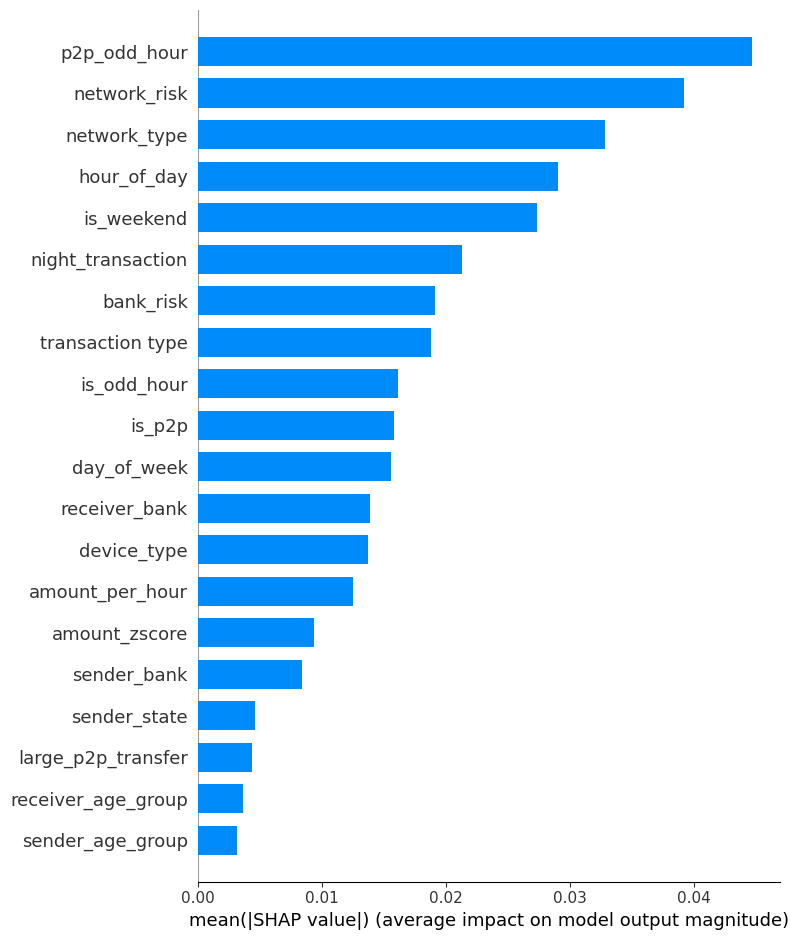

In [ ]:
shap.summary_plot(
    shap_values[:, :, 1],
    X_sample,
    plot_type="bar"
)

force plot for single transaction

In [ ]:
shap.initjs()

shap.force_plot(
    explainer.expected_value[0],
    shap_values[0, :, 0],
    X_sample.iloc[0]
)

dependence plot

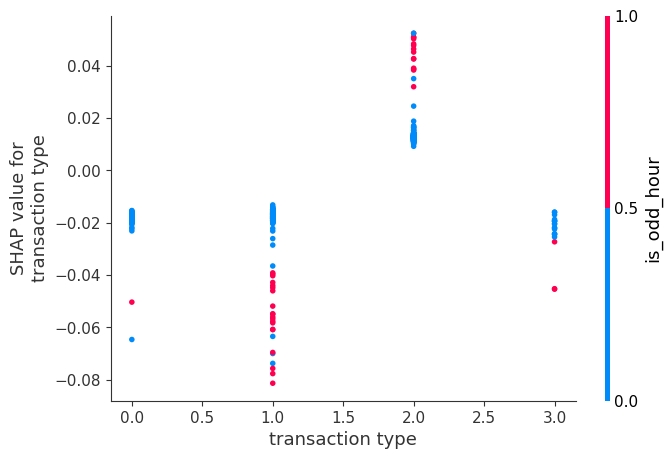

In [ ]:
shap.dependence_plot(

    "transaction type",

    shap_values[:, :, 1],

    X_sample

)

In [ ]:
shap_importance = pd.DataFrame({

    "Feature": X_sample.columns,

    "Mean_SHAP":

        np.abs(shap_values[:, :, 1]).mean(axis=0)

})

shap_importance = shap_importance.sort_values(

    by="Mean_SHAP",
    ascending=False

)

shap_importance

,Feature,Mean_SHAP
28,p2p_odd_hour,0.044738
22,network_risk,0.039258
9,network_type,0.032896
10,hour_of_day,0.029050
12,is_weekend,0.027402
16,night_transaction,0.021301
21,bank_risk,0.019188
0,transaction type,0.018821
26,is_odd_hour,0.016152
24,is_p2p,0.015830


LIME

In [ ]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 8.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=7982c9f5c0160f004cb9a5be8ed1410b4ca6082ec99f2f0c4cb13fdc9d2fb3c8
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [ ]:
import numpy as np
import pandas as pd

from lime.lime_tabular import LimeTabularExplainer

import torch

In [ ]:
def payshield_predict_proba(X):

    X_df = pd.DataFrame(
        X,
        columns=feature_names
    )

    rf_probs = calibrated_rf.predict_proba(X_df[mlp_feature_cols])[:, 1]
    with torch.no_grad():
        mlp_tensor = torch.tensor(
            X_df[mlp_feature_cols].values,
            dtype=torch.float32
        ).to(device)
        mlp_probs = mlp_model(
            mlp_tensor
        ).cpu().numpy().flatten()

    text_local = X_df['text_prob'].values

    # Final PayShield Weighted Voting (using the weights from the ablation study or final ensemble)
    final_probs = (
          0.60 * rf_probs    # w_rf_cal
        + 0.20 * mlp_probs   # w_mlp
        + 0.20 * text_local  # w_text
    )

    return np.vstack([
        1 - final_probs,
        final_probs
    ]).T

In [ ]:
feature_names = mlp_feature_cols + ['text_prob'] # Include text_prob as a feature for LIME

# Identify ALL categorical features from mlp_feature_cols (LabelEncoded or 0/1 boolean flags)
categorical_features_list = [
    'transaction type', 'merchant_category', 'transaction_status',
    'sender_age_group', 'receiver_age_group', 'sender_state',
    'sender_bank', 'receiver_bank', 'device_type', 'network_type',
    'day_of_week', 'is_weekend', 'high_amount', 'night_transaction',
    'senior_sender', 'senior_high_amount', 'night_high_txn',
    'is_p2p', 'is_senior', 'is_odd_hour', 'large_p2p_transfer',
    'p2p_odd_hour', 'senior_odd_hour'
]
categorical_feature_indices = [feature_names.index(col) for col in categorical_features_list if col in feature_names]

# Prepare training data for LIME with all features
X_train_for_lime = df_train_results[mlp_feature_cols + ['text_prob']]


lime_explainer = LimeTabularExplainer(
    training_data=X_train_for_lime.values,
    feature_names=feature_names,
    class_names=["Non-Fraud", "Fraud"],
    mode="classification",
    categorical_features=categorical_feature_indices,
    # Specify feature names for categorical data if available. This helps LIME.
    # categorical_names={i: feature_names[i] for i in categorical_feature_indices}
)

In [ ]:
# Fraud sample (class = 1)
fraud_index = np.where(y_test == 1)[0][20]

# Non-fraud sample (class = 0)
nonfraud_index = np.where(y_test == 0)[0][20]

In [ ]:
# Fraud instance
x_fraud = df_test_results.iloc[fraud_index][mlp_feature_cols + ['text_prob']].values

# Non-fraud instance
x_nonfraud = df_test_results.iloc[nonfraud_index][mlp_feature_cols + ['text_prob']].values

In [ ]:
# Fraud explanation
exp_fraud = lime_explainer.explain_instance(
    x_fraud,
    payshield_predict_proba,
    num_features=10
)

# Non-fraud explanation
exp_nonfraud = lime_explainer.explain_instance(
    x_nonfraud,
    payshield_predict_proba,
    num_features=10
)

In [ ]:
# Show in notebook
exp_fraud.show_in_notebook()
exp_nonfraud.show_in_notebook()

# OR print as list
print("Fraud Explanation:")
print(exp_fraud.as_list())

print("\nNon-Fraud Explanation:")
print(exp_nonfraud.as_list())

Fraud Explanation:
[('amount_per_hour > 148.20', -59.80600750084948), ('senior_odd_hour=0', 17.706739394995893), ('night_high_txn=0', -4.677401359027208), ('senior_high_amount=0', -4.348280081414894), ('network_type=0', 2.2529404493637637), ('hour_of_day <= 10.00', -1.7369518942805675), ('high_amount=0', -1.476579887246981), ('sender_state=4', 1.4635081586449652), ('night_transaction=1', -1.3495982058213412), ('receiver_bank=4', -1.0674157715644146)]

Non-Fraud Explanation:
[('51.55 < amount_per_hour <= 148.20', 19.313187503216753), ('senior_high_amount=0', -10.765309030118635), ('senior_odd_hour=0', 6.563021939498874), ('large_p2p_transfer=0', 6.108239859333582), ('high_amount=0', 3.5723016113689723), ('transaction_status=1', -2.9903650389102654), ('receiver_age_group=0', -2.8510779680690077), ('sender_bank=2', -2.2008895873942316), ('receiver_bank=6', -2.1746764693124256), ('p2p_odd_hour=0', 2.0827789590458483)]


## 10. Risk Bucketing Analysis

In [ ]:
from sklearn.metrics import precision_recall_curve
import pandas as pd

precision, recall, thresholds = precision_recall_curve(
    y_test,
    test_prob
)

pr_df = pd.DataFrame({
    "Threshold": thresholds,
    "Precision": precision[:-1],
    "Recall": recall[:-1]
})

print(pr_df.head())

   Threshold  Precision  Recall
0   0.004945   0.020040     1.0
1   0.004989   0.020040     1.0
2   0.005238   0.020041     1.0
3   0.005537   0.020041     1.0
4   0.005595   0.020042     1.0


In [ ]:
import numpy as np

f1_scores = 2 * (
    pr_df["Precision"] * pr_df["Recall"]
) / (
    pr_df["Precision"] + pr_df["Recall"]
)

pr_df["F1"] = f1_scores

best_threshold = pr_df.loc[
    pr_df["F1"].idxmax(),
    "Threshold"
]

print("Best Threshold:", best_threshold)

Best Threshold: 0.39696952386368567


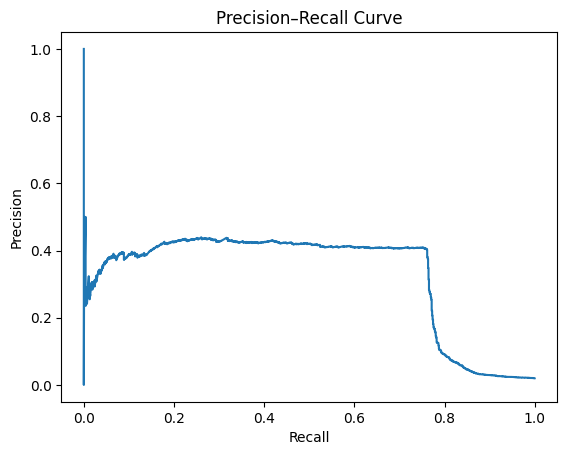

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(
    recall,
    precision
)

plt.xlabel("Recall")

plt.ylabel("Precision")

plt.title("Precision–Recall Curve")

plt.show()

In [ ]:
def assign_risk(prob):

    if prob < 0.10:
        return "Low Risk"

    elif prob < 0.40:
        return "Medium Risk"

    elif prob < 0.90:
        return "High Risk"

    else:
        return "Critical Risk"


df_test_results["risk_bucket"] = df_test_results[
    "probability"
].apply(assign_risk)

print(df_test_results["risk_bucket"].value_counts())

risk_bucket
Low Risk         44907
Medium Risk       3248
High Risk         1633
Critical Risk      212
Name: count, dtype: int64


In [ ]:
risk_summary = pd.crosstab(
    df_test_results["risk_bucket"],
    df_test_results["actual"]
)

risk_summary

actual,0,1
risk_bucket,,
Critical Risk,129,83
High Risk,963,670
Low Risk,44687,220
Medium Risk,3219,29


## **Final Buckets**

In [ ]:
df_test_results.columns

Index(['transaction type', 'merchant_category', 'transaction_status',
       'sender_age_group', 'receiver_age_group', 'sender_state', 'sender_bank',
       'receiver_bank', 'device_type', 'network_type', 'hour_of_day',
       'day_of_week', 'is_weekend', 'txn_day', 'txn_month', 'high_amount',
       'night_transaction', 'senior_sender', 'senior_high_amount',
       'amount_zscore', 'night_high_txn', 'bank_risk', 'network_risk',
       'amount_per_hour', 'is_p2p', 'is_senior', 'is_odd_hour',
       'large_p2p_transfer', 'p2p_odd_hour', 'senior_odd_hour', 'actual',
       'predicted', 'probability', 'risk_bucket', 'probability_calibrated',
       'risk_bucket_calibrated', 'prob_rf_calibrated', 'pred_rf_calibrated',
       'transaction_notes', 'clean_text', 'text_pred', 'text_prob',
       'hybrid_prob_alpha_0.03', 'hybrid_prob_alpha_0.05',
       'hybrid_prob_alpha_0.07', 'hybrid_prob_alpha_0.1',
       'risk_bucket_hybrid_0.03', 'risk_bucket_hybrid_0.05',
       'risk_bucket_hybrid_0.0

In [ ]:
import numpy as np

scores = df_test_results["payshield_final"]


low_thresh = np.percentile(scores, 40)

moderate_thresh = np.percentile(scores, 70)

high_thresh = np.percentile(scores, 90)

print("Improved PaySHIELD Thresholds:")

print(f"Low Threshold: {low_thresh:.4f}")
print(f"Moderate Threshold: {moderate_thresh:.4f}")
print(f"High Threshold: {high_thresh:.4f}")


def payshield_layer(score):

    if score >= high_thresh:
        return pd.Series([
            "HIGH",
            "BLOCK",
            "High Fraud Risk — Blocked"
        ])

    elif score >= moderate_thresh:
        return pd.Series([
            "MODERATE",
            "VERIFY",
            "Moderate Risk — OTP Required"
        ])

    elif score >= low_thresh:
        return pd.Series([
            "LOW-MODERATE",
            "ALLOW_WITH_ALERT",
            "Monitor Transaction"
        ])

    else:
        return pd.Series([
            "LOW",
            "ALLOW",
            "Approved"
        ])

df_test_results[
    ["Risk_Block",
     "System_Action",
     "Alert_Message"]
] = df_test_results["payshield_final"].apply(
        payshield_layer
)



print("\nNew Risk Distribution:\n")

print(
    df_test_results["Risk_Block"]
    .value_counts()
)

Improved PaySHIELD Thresholds:
Low Threshold: 0.0055
Moderate Threshold: 0.0136
High Threshold: 0.1563

New Risk Distribution:

Risk_Block
LOW             20000
LOW-MODERATE    15000
MODERATE        10000
HIGH             5000
Name: count, dtype: int64


In [ ]:
def payshield_decision_engine(score):

    if score >= 0.0620:
        return pd.Series([
            "HIGH",
            "BLOCK",
            "🚨 Transaction Blocked: High Fraud Risk"
        ])

    elif score >= 0.0243:
        return pd.Series([
            "MODERATE",
            "VERIFY",
            "⚠️ OTP Verification Required"
        ])

    elif score >= 0.0117:
        return pd.Series([
            "LOW-MODERATE",
            "ALLOW_WITH_ALERT",
            "🔎 Transaction Logged for Monitoring"
        ])

    else:
        return pd.Series([
            "LOW",
            "ALLOW",
            "✅ Transaction Approved"
        ])

df_test_results[
    ["Risk_Block",
     "System_Action",
     "Alert_Message"]
] = df_test_results["payshield_final"].apply(
        payshield_decision_engine
)

In [ ]:
fraud_summary = (
    df_test_results
    .groupby("Risk_Block")["actual"]
    .agg(
        Total_Transactions="count",
        Fraud_Count="sum"
    )
)

fraud_summary["Fraud_Rate"] = (
    fraud_summary["Fraud_Count"] /
    fraud_summary["Total_Transactions"]
)

print("\nFraud Rate per Risk Block:\n")
print(fraud_summary)


Fraud Rate per Risk Block:

              Total_Transactions  Fraud_Count  Fraud_Rate
Risk_Block                                               
HIGH                        8644          906    0.104813
LOW                        33514           38    0.001134
LOW-MODERATE                5003           23    0.004597
MODERATE                    2839           35    0.012328


In [ ]:
total_fraud = df_test_results["actual"].sum()

fraud_capture = (
    df_test_results
    .groupby("Risk_Block")["actual"]
    .sum()
    / total_fraud
)

fraud_capture = fraud_capture.sort_values(
    ascending=False
)

print("\nFraud Capture Rate per Risk Block:\n")
print(fraud_capture)


Fraud Capture Rate per Risk Block:

Risk_Block
HIGH            0.904192
LOW             0.037924
MODERATE        0.034930
LOW-MODERATE    0.022954
Name: actual, dtype: float64


## Tab transformer+ResNet

In [ ]:
# df_train_results.head()

In [ ]:
# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# from torch.utils.data import DataLoader, TensorDataset
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import precision_score, recall_score, f1_score
# import numpy as np
# import pandas as pd

In [ ]:
# feature_cols = [
#     'transaction type','merchant_category','transaction_status',
#     'sender_age_group','receiver_age_group','sender_state',
#     'sender_bank','receiver_bank','device_type','network_type',
#     'hour_of_day','day_of_week','p2p_odd_hour','senior_odd_hour'
# ]

# target_col = 'fraud_text_flag'

# X = df_train_results[feature_cols].values
# y = df_train_results[target_col].values

# # Train/Val split
# X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# # Convert to torch tensors
# X_train = torch.tensor(X_train, dtype=torch.float32)
# X_val = torch.tensor(X_val, dtype=torch.float32)
# y_train = torch.tensor(y_train, dtype=torch.long)
# y_val = torch.tensor(y_val, dtype=torch.long)

In [ ]:
# batch_size = 128
# train_dataset = TensorDataset(X_train, y_train)
# val_dataset = TensorDataset(X_val, y_val)

# train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
# val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
# class_counts = torch.bincount(y_train)
# weight = class_counts.float().sum() / (2 * class_counts.float())
# class_weights = torch.tensor([weight[0], weight[1]], dtype=torch.float).to(device)
# criterion = nn.CrossEntropyLoss(weight=class_weights)

In [ ]:
# import torch
# import torch.nn as nn
# import torch.nn.functional as F

# # Placeholder TabTransformer for demonstration and to resolve the missing definition
# # In a real scenario, you would import this from a library or define its actual structure.
# class TabTransformer(nn.Module):
#     def __init__(self, feature_dim, embed_dim, num_heads, num_layers):
#         super().__init__()
#         self.linear = nn.Linear(feature_dim, embed_dim) # Simple linear layer to produce embed_dim features

#     def forward(self, x):
#         return self.linear(x)


# class ResBlock1D(nn.Module):
#     def __init__(self, in_channels, out_channels, kernel_size=3):
#         super().__init__()
#         self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size, padding=kernel_size//2)
#         self.norm1 = nn.BatchNorm1d(out_channels)
#         self.relu = nn.ReLU()
#         self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size, padding=kernel_size//2)
#         self.norm2 = nn.BatchNorm1d(out_channels)
#         self.skip = nn.Conv1d(in_channels, out_channels, kernel_size=1) if in_channels != out_channels else nn.Identity()

#     def forward(self, x):
#         identity = self.skip(x)
#         out = self.conv1(x)
#         out = self.norm1(out)
#         out = self.relu(out)
#         out = self.conv2(out)
#         out = self.norm2(out)
#         out += identity
#         out = self.relu(out)
#         return out

# class TabResNetHybrid(nn.Module):
#     def __init__(self, input_features, num_classes=2, embed_dim=64):
#         super().__init__()
#         # Simple linear embedding
#         self.embedding = nn.Linear(input_features, embed_dim)

#         # ResNet blocks
#         self.resblock1 = ResBlock1D(embed_dim, 128)
#         self.resblock2 = ResBlock1D(128, 64)

#         # Final classifier
#         self.fc = nn.Linear(64, num_classes)

#     def forward(self, x):
#         x = self.embedding(x)
#         x = x.unsqueeze(-1)
#         x = self.resblock1(x)
#         x = self.resblock2(x)
#         x = x.squeeze(-1)
#         out = self.fc(x)
#         return out

# # --------------------------
# # Full Hybrid Model
# class TransformerResNetHybrid(nn.Module):
#     def __init__(self, input_features, num_classes=2):
#         super().__init__()
#         self.transformer_output_dim = 128
#         # Now TabTransformer is explicitly defined or imported
#         self.transformer = TabTransformer(feature_dim=input_features, embed_dim=self.transformer_output_dim, num_heads=4, num_layers=2)

#         self.resblock1 = ResBlock1D(in_channels=self.transformer_output_dim, out_channels=128)
#         self.resblock2 = ResBlock1D(in_channels=128, out_channels=64)
#         self.fc = nn.Linear(64, num_classes)

#     def forward(self, x):
#       x = self.transformer(x)          # Should output [batch, self.transformer_output_dim]
#       x = x.unsqueeze(-1)              # [batch, self.transformer_output_dim, 1]
#       x = self.resblock1(x)
#       x = self.resblock2(x)
#       x = x.squeeze(-1)
#       out = self.fc(x)
#       return out

# # --------------------------
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model = TransformerResNetHybrid(input_features=X_train.shape[1], num_classes=2).to(device)

In [ ]:
# optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

In [ ]:
# for X_batch, y_batch in train_loader:
#     print("X_batch shape:", X_batch.shape)
#     break

In [ ]:
# num_epochs = 30
# best_val_precision = 0

# for epoch in range(num_epochs):
#     model.train()
#     for X_batch, y_batch in train_loader:
#         X_batch, y_batch = X_batch.to(device), y_batch.to(device)
#         optimizer.zero_grad()
#         outputs = model(X_batch)
#         loss = criterion(outputs, y_batch)
#         loss.backward()
#         optimizer.step()

#     # Validation
#     model.eval()
#     all_preds, all_labels = [], []
#     with torch.no_grad():
#         for X_batch, y_batch in val_loader:
#             X_batch, y_batch = X_batch.to(device), y_batch.to(device)
#             outputs = model(X_batch)
#             probs = torch.softmax(outputs, dim=1)[:,1]  # prob of class 1
#             all_preds.append(probs.cpu())
#             all_labels.append(y_batch.cpu())

#     all_preds = torch.cat(all_preds).numpy()
#     all_labels = torch.cat(all_labels).numpy()

#     # Threshold tuning for max precision
#     thresholds = np.arange(0.1, 0.9, 0.05)
#     best_thresh = 0.5
#     best_prec = 0
#     for t in thresholds:
#         preds_bin = (all_preds >= t).astype(int)
#         prec = precision_score(all_labels, preds_bin, zero_division=0)
#         if prec > best_prec:
#             best_prec = prec
#             best_thresh = t

#     # Metrics
#     preds_bin = (all_preds >= best_thresh).astype(int)
#     recall = recall_score(all_labels, preds_bin)
#     f1 = f1_score(all_labels, preds_bin)

#     print(f"Epoch {epoch+1}/{num_epochs} | Threshold: {best_thresh:.2f} | Precision: {best_prec:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}")
#     scheduler.step(best_prec)

#     if best_prec > best_val_precision:
#         best_val_precision = best_prec
#         torch.save(model.state_dict(), "best_precision_model.pth")

In [ ]:
# model.load_state_dict(torch.load("best_precision_model.pth"))
# model.eval()

# X_new = torch.tensor(df_train_results[feature_cols].values, dtype=torch.float32).to(device)
# with torch.no_grad():
#     probs = torch.softmax(model(X_new), dim=1)[:,1].cpu().numpy()
#     preds = (probs >= best_thresh).astype(int)

# df_train_results['pred_hybrid'] = preds
# df_train_results['prob_hybrid'] = probs

## **14.Combining probabilities and text based results**

In [ ]:
alpha_values = [0.03, 0.05, 0.07, 0.10]

for alpha in alpha_values:

    col_name = f"hybrid_prob_alpha_{alpha}"

    df_test_results[col_name] = (
        df_test_results["prob_rf_calibrated"]
        + alpha * df_test_results["text_prob"]
    )

    df_test_results[col_name] = df_test_results[
        col_name
    ].clip(0, 1)

print("Hybrid probability columns created.")

Hybrid probability columns created.


In [ ]:
# Create risk buckets for each alpha

for alpha in alpha_values:

    prob_col = f"hybrid_prob_alpha_{alpha}"
    bucket_col = f"risk_bucket_hybrid_{alpha}"

    df_test_results[bucket_col] = pd.qcut(
        df_test_results[prob_col],
        q=4,
        labels=[
            "Low Risk",
            "Medium Risk",
            "High Risk",
            "Critical Risk"
        ]
    )

print("Hybrid risk buckets created.")

Hybrid risk buckets created.


In [ ]:
for alpha in alpha_values:

    bucket_col = f"risk_bucket_hybrid_{alpha}"

    print(f"\n========== Alpha = {alpha} ==========\n")

    table = pd.crosstab(
        df_test_results[bucket_col],
        df_test_results["actual"]
    )

    print(table)


========== Alpha = 0.03 ==========

actual                       0    1
risk_bucket_hybrid_0.03            
Low Risk                 12757   20
Medium Risk              12238   23
High Risk                12425   40
Critical Risk            11578  919

========== Alpha = 0.05 ==========

actual                       0    1
risk_bucket_hybrid_0.05            
Low Risk                 12493   20
Medium Risk              12477   16
High Risk                12448   49
Critical Risk            11580  917

========== Alpha = 0.07 ==========

actual                       0    1
risk_bucket_hybrid_0.07            
Low Risk                 12527   19
Medium Risk              12440   14
High Risk                12450   50
Critical Risk            11581  919

========== Alpha = 0.1 ==========

actual                      0    1
risk_bucket_hybrid_0.1            
Low Risk                12620   19
Medium Risk             12392   13
High Risk               12407   49
Critical Risk           11579 

In [ ]:
total_fraud = df_test_results["actual"].sum()

for alpha in alpha_values:

    bucket_col = f"risk_bucket_hybrid_{alpha}"

    critical_fraud = df_test_results[

        (df_test_results[bucket_col] == "Critical Risk") &
        (df_test_results["actual"] == 1)

    ].shape[0]

    capture_rate = (
        critical_fraud / total_fraud
    ) * 100

    print(
        f"Alpha {alpha} → "
        f"Critical Fraud Capture: "
        f"{capture_rate:.2f}%"
    )

Alpha 0.03 → Critical Fraud Capture: 91.72%
Alpha 0.05 → Critical Fraud Capture: 91.52%
Alpha 0.07 → Critical Fraud Capture: 91.72%
Alpha 0.1 → Critical Fraud Capture: 91.92%


In [ ]:
# Final alpha selection
alpha_final = 0.03


# Create final hybrid probability
df_test_results["hybrid_probability"] = (
    df_test_results["prob_rf_calibrated"]
    + alpha_final * df_test_results["text_prob"]
)

df_test_results["hybrid_probability"] = df_test_results[
    "hybrid_probability"
].clip(0, 1)


# Create final hybrid buckets
df_test_results["risk_bucket_final"] = pd.qcut(
    df_test_results["hybrid_probability"],
    q=4,
    labels=[
        "Low Risk",
        "Medium Risk",
        "High Risk",
        "Critical Risk"
    ]
)

print("Final hybrid buckets created.")

Final hybrid buckets created.


In [ ]:
# Define threshold
threshold = 0.50

# Create final predictions
df_test_results["hybrid_predicted"] = (
    df_test_results["hybrid_probability"] >= threshold
).astype(int)

print("Hybrid predictions created.")

Hybrid predictions created.


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    df_test_results["actual"],
    df_test_results["hybrid_predicted"]
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[47735  1263]
 [  238   764]]


In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        df_test_results["actual"],
        df_test_results["hybrid_predicted"]
    )
)

              precision    recall  f1-score   support

           0       1.00      0.97      0.98     48998
           1       0.38      0.76      0.50      1002

    accuracy                           0.97     50000
   macro avg       0.69      0.87      0.74     50000
weighted avg       0.98      0.97      0.97     50000



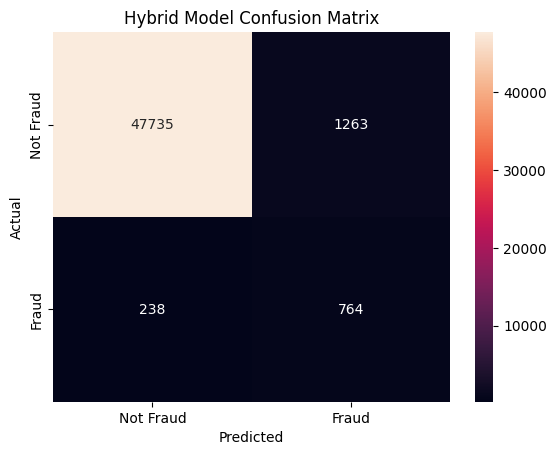

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Not Fraud", "Fraud"],
    yticklabels=["Not Fraud", "Fraud"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Hybrid Model Confusion Matrix")

plt.show()

In [ ]:
print("Random Forest Performance:\n")

print(
    classification_report(
        df_test_results["actual"],
        df_test_results["pred_rf_calibrated"]
    )
)


print("\nHybrid Performance:\n")

print(
    classification_report(
        df_test_results["actual"],
        df_test_results["hybrid_predicted"]
    )
)

Random Forest Performance:

              precision    recall  f1-score   support

           0       1.00      0.97      0.98     48998
           1       0.37      0.76      0.49      1002

    accuracy                           0.97     50000
   macro avg       0.68      0.87      0.74     50000
weighted avg       0.98      0.97      0.97     50000


Hybrid Performance:

              precision    recall  f1-score   support

           0       1.00      0.97      0.98     48998
           1       0.38      0.76      0.50      1002

    accuracy                           0.97     50000
   macro avg       0.69      0.87      0.74     50000
weighted avg       0.98      0.97      0.97     50000



In [ ]:
from sklearn.metrics import precision_recall_curve
import numpy as np

# True labels
y_true = df_test_results["actual"]

# Hybrid probabilities
y_prob = df_test_results["hybrid_probability"]

# Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(
    y_true,
    y_prob
)

# Compute F1 scores
f1_scores = 2 * (precision * recall) / (
    precision + recall + 1e-9
)

# Find best threshold
best_index = np.argmax(f1_scores)

best_threshold = thresholds[best_index]

print("Best Threshold (F1-based):", best_threshold)

print("Best F1 Score:", f1_scores[best_index])
print("Precision at best threshold:", precision[best_index])
print("Recall at best threshold:", recall[best_index])

Best Threshold (F1-based): 0.8093802478993826
Best F1 Score: 0.5737356561195844
Precision at best threshold: 0.4996299037749815
Recall at best threshold: 0.6736526946107785


In [ ]:
df_test_results["hybrid_predicted"] = (
    df_test_results["hybrid_probability"]
    >= best_threshold
).astype(int)

print("Predictions created using statistical threshold.")

Predictions created using statistical threshold.


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    df_test_results["actual"],
    df_test_results["hybrid_predicted"]
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[48322   676]
 [  327   675]]


In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        df_test_results["actual"],
        df_test_results["hybrid_predicted"]
    )
)

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     48998
           1       0.50      0.67      0.57      1002

    accuracy                           0.98     50000
   macro avg       0.75      0.83      0.78     50000
weighted avg       0.98      0.98      0.98     50000



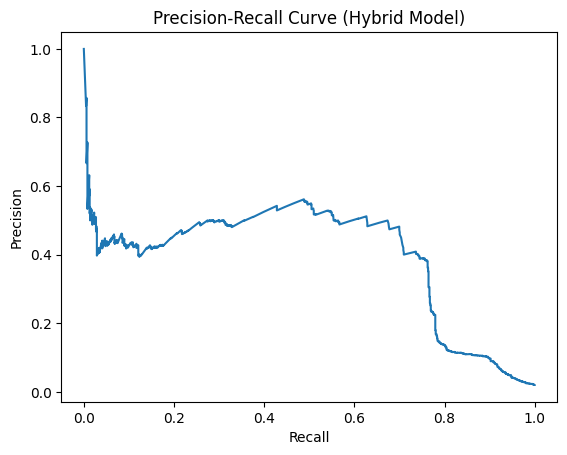

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(recall, precision)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (Hybrid Model)")

plt.show()

## LLM integration

In [ ]:
!pip install groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.7/141.7 kB 6.4 MB/s eta 0:00:00


In [ ]:
# Create decoded dataframe
decoded_df = df.copy()

for col, le in le_dict.items():

    decoded_df[col] = le.inverse_transform(
        decoded_df[col].astype(int)
    )

print("Decoded sample:")
decoded_df.head()

Decoded sample:


,transaction id,timestamp,transaction type,merchant_category,amount (INR),transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,...,bank_risk,network_risk,amount_per_hour,is_p2p,is_senior,is_odd_hour,large_p2p_transfer,p2p_odd_hour,senior_odd_hour,clean_text
0,TXN0000000001,2024-10-08 15:17:00,P2P,Entertainment,868,SUCCESS,26-35,18-25,Delhi,Axis,...,0.019686,0.019431,54.250000,1,0,0,0,0,0,zomato food order
1,TXN0000000002,2024-04-11 06:56:00,P2M,Grocery,1011,SUCCESS,26-35,26-35,Uttar Pradesh,ICICI,...,0.019606,0.019431,144.428571,0,0,0,0,0,0,payment to milkman
2,TXN0000000003,2024-04-02 13:27:00,P2P,Grocery,477,SUCCESS,26-35,36-45,Karnataka,Yes Bank,...,0.022458,0.019431,34.071429,1,0,0,0,0,0,petrol for bike
3,TXN0000000004,2024-01-07 10:09:00,P2P,Fuel,2784,SUCCESS,26-35,26-35,Delhi,ICICI,...,0.022458,0.020309,253.090909,1,0,0,0,0,0,office coffee split
4,TXN0000000005,2024-01-23 19:04:00,P2P,Shopping,990,SUCCESS,26-35,18-25,Delhi,Axis,...,0.020593,0.022121,49.500000,1,0,0,0,0,0,zomato food order


In [ ]:
def create_reasoning_prompt(row):

    prompt = f"""
You are a financial fraud detection expert.

Analyze this transaction and explain if it is fraudulent.

Transaction Details:

- Transaction type: {row['transaction type']}
- Merchant category: {row['merchant_category']}
- Transaction status: {row['transaction_status']}
- Sender age group: {row['sender_age_group']}
- Receiver age group: {row['receiver_age_group']}
- Sender state: {row['sender_state']}
- Sender bank: {row['sender_bank']}
- Receiver bank: {row['receiver_bank']}
- Device type: {row['device_type']}
- Network type: {row['network_type']}
- Hour of day: {row['hour_of_day']}
- Day of week: {row['day_of_week']}

Return:

Fraud: Yes or No
Reason: Explain why.
"""

    return prompt

In [ ]:
def get_llm_response(prompt):

    response = client.chat.completions.create(

        model="llama-3.1-8b-instant",

        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ],

        temperature=0.2,
        max_tokens=200
    )

    return response.choices[0].message.content

In [ ]:
decoded_test_df = df_test_results.copy()

for col, le in le_dict.items():

    if col in decoded_test_df.columns:

        decoded_test_df[col] = le.inverse_transform(
            decoded_test_df[col].astype(int)
        )

print("Decoded sample:")
decoded_test_df.head()

Decoded sample:


,transaction type,merchant_category,transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,receiver_bank,device_type,network_type,...,cal_rf_only,mlp_only,text_only,rf_mlp,rf_text,mlp_text,payshield_final,Risk_Block,System_Action,Alert_Message
87892,P2P,Grocery,SUCCESS,36-45,18-25,Maharashtra,Axis,Kotak,iOS,4G,...,0.004604,8.912291e-15,1,0.003223,0.008905,0.010444,0.007984,LOW,ALLOW,✅ Transaction Approved
9122,Bill Payment,Grocery,SUCCESS,18-25,26-35,Karnataka,PNB,ICICI,Android,5G,...,0.015050,6.263583e-06,0,0.010537,0.013951,0.003825,0.010942,LOW,ALLOW,✅ Transaction Approved
96866,P2P,Fuel,SUCCESS,36-45,36-45,Delhi,ICICI,PNB,Android,4G,...,0.022890,1.511250e-08,1,0.016023,0.172776,0.308927,0.168198,HIGH,BLOCK,🚨 Transaction Blocked: High Fraud Risk
55488,Bill Payment,Food,SUCCESS,26-35,36-45,Telangana,IndusInd,SBI,Android,4G,...,0.004604,5.142986e-05,0,0.003238,0.004619,0.001903,0.003709,LOW,ALLOW,✅ Transaction Approved
157778,P2P,Fuel,SUCCESS,18-25,18-25,Uttar Pradesh,SBI,IndusInd,Web,4G,...,0.019376,1.480683e-20,0,0.013563,0.016070,0.001138,0.012195,LOW-MODERATE,ALLOW_WITH_ALERT,🔎 Transaction Logged for Monitoring


In [ ]:
eval_df = decoded_test_df.sample(
    n=5000,
    random_state=42
).reset_index(drop=True)

In [ ]:
print("Eval DF shape:", eval_df.shape)

Eval DF shape: (5000, 79)


In [ ]:
small_test_df = eval_df.head(10)

In [ ]:
results = []

for i, row in small_test_df.iterrows():

    prompt = create_reasoning_prompt(row)

    output = get_llm_response(prompt)

    print("\nSample:", i)
    print(output)

    results.append(output)


Sample: 0
Based on the provided transaction details, I would classify this transaction as potentially fraudulent. Here's why:

1. **Unusual age group combination**: The sender is in the 18-25 age group, while the receiver is in the 26-35 age group. This combination is unusual, as typically, transactions between individuals of the same age group or close age groups are more common.

2. **Different bank accounts**: The sender's bank is Axis, while the receiver's bank is PNB. This could indicate a money laundering or transfer scheme, as the sender might be using a different bank account to disguise the transaction.

3. **High-risk hour of day**: The transaction occurred at 19:00 hours on a Sunday, which is considered a high-risk hour for fraud. Sundays are typically considered a low-risk day for transactions, but the late hour increases the likelihood of fraudulent activity.

4. **Device and network type**: The transaction was initiated from an iOS device over a 4

Sample: 1
Based on the

In [ ]:
fraud_df = decoded_df[decoded_df["fraud_flag"] == 1]
normal_df = decoded_df[decoded_df["fraud_flag"] == 0]

print("Fraud cases:", fraud_df.shape)
print("Normal cases:", normal_df.shape)

Fraud cases: (5008, 38)
Normal cases: (244992, 38)


In [ ]:
def get_top_patterns(column):

    fraud_dist = fraud_df[column].value_counts(normalize=True)

    normal_dist = normal_df[column].value_counts(normalize=True)

    diff = fraud_dist - normal_dist

    suspicious = diff.sort_values(ascending=False)

    return suspicious.head(5)

for col in [
    "transaction type",
    "merchant_category",
    "transaction_status",
    "device_type",
    "network_type",
    "hour_of_day"
]:

    print("\nTop suspicious values for:", col)

    print(get_top_patterns(col))


Top suspicious values for: transaction type
transaction type
P2P             0.418426
Recharge       -0.038499
Bill Payment   -0.113609
P2M            -0.266318
Name: proportion, dtype: float64

Top suspicious values for: merchant_category
merchant_category
Education     0.054363
Utilities     0.023947
Shopping      0.021111
Healthcare   -0.002784
Other        -0.009445
Name: proportion, dtype: float64

Top suspicious values for: transaction_status
transaction_status
FAILED     0.000628
SUCCESS   -0.000628
Name: proportion, dtype: float64

Top suspicious values for: device_type
device_type
Web        0.001711
iOS        0.001457
Android   -0.003168
Name: proportion, dtype: float64

Top suspicious values for: network_type
network_type
WiFi    0.010701
3G      0.004112
5G      0.003537
4G     -0.018350
Name: proportion, dtype: float64

Top suspicious values for: hour_of_day
hour_of_day
23    0.196523
0     0.114949
1     0.070308
5     0.063188
2     0.054251
Name: proportion, dtype: fl

In [ ]:
suspicious_hours = fraud_df["hour_of_day"].value_counts().head(5).index.tolist()

suspicious_device = fraud_df["device_type"].value_counts().head(3).index.tolist()

suspicious_network = fraud_df["network_type"].value_counts().head(3).index.tolist()

print("Suspicious hours:", suspicious_hours)
print("Suspicious devices:", suspicious_device)
print("Suspicious networks:", suspicious_network)

Suspicious hours: [23, 0, 1, 5, 2]
Suspicious devices: ['Android', 'iOS', 'Web']
Suspicious networks: ['4G', '5G', 'WiFi']


In [ ]:
def create_reasoning_prompt(row):

    return f"""
You are a fraud detection system.

Use ONLY the fraud indicators below.

Fraud Indicators:

1. Transactions during hours {suspicious_hours} are suspicious.
2. Device types {suspicious_device} are frequently used in fraud.
3. Network types {suspicious_network} are risky.
4. Failed transactions are suspicious.
5. Unusual merchant categories are risky.

Transaction:

Transaction type: {row['transaction type']}
Merchant category: {row['merchant_category']}
Transaction status: {row['transaction_status']}
Sender age group: {row['sender_age_group']}
Receiver age group: {row['receiver_age_group']}
Sender state: {row['sender_state']}
Sender bank: {row['sender_bank']}
Receiver bank: {row['receiver_bank']}
Device type: {row['device_type']}
Network type: {row['network_type']}
Hour: {row['hour_of_day']}
Day: {row['day_of_week']}

Instructions:

Check if this transaction matches fraud indicators.

Return ONLY:

Fraud: Yes or No
Reason: Which indicators matched.
"""

In [ ]:
for i, row in small_test_df.iterrows():

    prompt = create_reasoning_prompt(row)

    output = get_llm_response(prompt)

    print("\nSample:", i)
    print(output)


Sample: 0
Fraud: No
Reason: None of the indicators matched. 

However, the transaction hour is close to the suspicious hours [23, 0, 1, 5, 2].

Sample: 1
Fraud: No
Reason: None of the indicators matched. 

The transaction occurred at 11, which is not within the suspicious hours [23, 0, 1, 5, 2]. 
The device type is Android, which is a frequently used device type in fraud, but this is the only indicator that matches. 
However, since there are other indicators that did not match, the overall transaction is not flagged as suspicious.

Sample: 2
Fraud: No
Reason: None of the indicators matched. 

- The transaction hour (6) does not match the suspicious hours [23, 0, 1, 5, 2].
- The device type 'iOS' is in the list of frequently used devices in fraud, but it's not the only indicator.
- The network type '5G' is in the list of risky networks.
- However, since the device type 'iOS' is in the list of frequently used devices in fraud, it can be considered a contributing factor.
- The transactio

In [ ]:
fraud_df = decoded_df[decoded_df["fraud_flag"] == 1]
normal_df = decoded_df[decoded_df["fraud_flag"] == 0]

def risk_values(column, top_n=5):

    fraud_dist = fraud_df[column].value_counts(normalize=True)

    normal_dist = normal_df[column].value_counts(normalize=True)

    diff = fraud_dist - normal_dist

    return diff.sort_values(
        ascending=False
    ).head(top_n).index.tolist()


suspicious_hours = risk_values("hour_of_day", 5)

suspicious_device = risk_values("device_type", 3)

suspicious_network = risk_values("network_type", 3)

suspicious_status = risk_values("transaction_status", 2)

print("Suspicious hours:", suspicious_hours)
print("Suspicious devices:", suspicious_device)
print("Suspicious networks:", suspicious_network)
print("Suspicious status:", suspicious_status)

Suspicious hours: [23, 0, 1, 5, 2]
Suspicious devices: ['Web', 'iOS', 'Android']
Suspicious networks: ['WiFi', '3G', '5G']
Suspicious status: ['FAILED', 'SUCCESS']


In [ ]:
def create_reasoning_prompt(row):

    return f"""
You are a fraud detection system.

Use the scoring rules below.

Risk Rules:

+3 points → Failed transaction
+2 points → Hour in {suspicious_hours}
+1 point → Device in {suspicious_device}
+1 point → Network in {suspicious_network}

Decision Rule:

Total Score ≥ 4 → Fraud
Total Score < 4 → Not Fraud

Transaction:

Hour: {row['hour_of_day']}
Transaction status: {row['transaction_status']}
Device type: {row['device_type']}
Network type: {row['network_type']}

Instructions:

1. Calculate risk score
2. Show score
3. Decide fraud

Return EXACT format:

Fraud: Yes or No
Score: number
Reason: Explain matched rules.
"""

In [ ]:
for i, row in small_test_df.iterrows():

    prompt = create_reasoning_prompt(row)

    output = get_llm_response(prompt)

    print("\nSample:", i)
    print(output)


Sample: 0
**Fraud Detection System**

**Transaction Details:**

- Hour: 19
- Transaction status: SUCCESS
- Device type: iOS
- Network type: 4G

**Risk Score Calculation:**

- No failed transaction, so +3 points = 0
- Hour is not in [23, 0, 1, 5, 2], so +2 points = 2
- Device type is 'iOS', so +1 point = 3
- Network type is not in ['WiFi', '3G', '5G'], so +1 point = 4

**Risk Score:** 4

**Decision Rule:**
Total Score ≥ 4 → Fraud
Total Score < 4 → Not Fraud

**Fraud Decision:** Yes

**Reason:** The transaction occurred at hour 19, which is not in the specified list, and the device type is 'iOS'.

Sample: 1
**Fraud Detection System**

**Transaction Details:**

- Hour: 11
- Transaction status: SUCCESS
- Device type: Android
- Network type: 4G

**Risk Score Calculation:**

- No failed transaction (+3 points) since the transaction status is SUCCESS.
- No hour in [23, 0, 1, 5, 2] since the hour is 11.
- Device type is Android (+1 point).
- Network type is 4G, which is not in the list ['WiFi

In [ ]:
import numpy as np
import pandas as pd

# Stratified sampling (keeps fraud ratio)

eval_sample = (
    eval_df
    .groupby("actual", group_keys=False)
    .apply(
        lambda x: x.sample(
            min(len(x), 50),
            random_state=42
        )
    )
)

# Shuffle
eval_sample = eval_sample.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print("Evaluation sample shape:", eval_sample.shape)

print(
    eval_sample["actual"].value_counts()
)

Evaluation sample shape: (100, 79)
actual
1    50
0    50
Name: count, dtype: int64


/tmp/ipykernel_13535/1192944181.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


In [ ]:
import re

def extract_prediction(text):

    text = text.lower()

    if "fraud: yes" in text:
        return 1

    if "fraud: no" in text:
        return 0

    if "**fraud:** yes" in text:
        return 1

    if "**fraud:** no" in text:
        return 0

    if "decision: fraud" in text:
        return 1

    if "decision: not fraud" in text:
        return 0

    # fallback safety
    return 0

In [ ]:
from tqdm import tqdm

outputs = []

y_true = []
y_pred = []

fraud_count = 0
nonfraud_count = 0

print("\n🚀 Running Evaluation on 100 Samples...\n")


for i, row in tqdm(
        eval_sample.iterrows(),
        total=len(eval_sample)
):

    # Create prompt
    prompt = create_reasoning_prompt(row)

    # Get response
    output = get_llm_response(prompt)

    outputs.append(output)

    # Extract prediction
    pred = extract_prediction(output)

    y_pred.append(pred)

    true_val = row["actual"]

    y_true.append(true_val)

    # Count predictions
    if pred == 1:
        fraud_count += 1
    else:
        nonfraud_count += 1


    # Logging every 20 samples
    if i % 20 == 0:

        print("\nProcessed:", i)

        print(
            "Fraud Predictions:",
            fraud_count
        )

        print(
            "Non-Fraud Predictions:",
            nonfraud_count
        )


print("\n✅ Evaluation Completed")

print("Total Samples:", len(y_pred))


🚀 Running Evaluation on 100 Samples...



  1%|          | 1/100 [00:03<05:31,  3.34s/it]


Processed: 0
Fraud Predictions: 0
Non-Fraud Predictions: 1


 21%|██        | 21/100 [01:22<04:53,  3.71s/it]


Processed: 20
Fraud Predictions: 2
Non-Fraud Predictions: 19


 41%|████      | 41/100 [02:40<03:55,  4.00s/it]


Processed: 40
Fraud Predictions: 3
Non-Fraud Predictions: 38


 61%|██████    | 61/100 [03:57<02:33,  3.95s/it]


Processed: 60
Fraud Predictions: 6
Non-Fraud Predictions: 55


 81%|████████  | 81/100 [05:13<01:16,  4.03s/it]


Processed: 80
Fraud Predictions: 8
Non-Fraud Predictions: 73


100%|██████████| 100/100 [06:21<00:00,  3.82s/it]


✅ Evaluation Completed
Total Samples: 100


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    matthews_corrcoef,
    balanced_accuracy_score,
    classification_report
)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

accuracy = accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_true,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_true,
    y_pred,
    zero_division=0
)

tn, fp, fn, tp = confusion_matrix(
    y_true,
    y_pred
).ravel()

specificity = tn / (tn + fp)

fpr = fp / (fp + tn)

fnr = fn / (fn + tp)

mcc = matthews_corrcoef(
    y_true,
    y_pred
)

balanced_acc = balanced_accuracy_score(
    y_true,
    y_pred
)

print("\n FINAL METRICS\n")

print("Accuracy:", accuracy)

print("Precision:", precision)

print("Recall:", recall)

print("F1 Score:", f1)

print("Specificity:", specificity)

print("FPR:", fpr)

print("FNR:", fnr)

print("MCC:", mcc)

print("Balanced Accuracy:", balanced_acc)

print("\nConfusion Matrix:")

print(
    confusion_matrix(
        y_true,
        y_pred
    )
)

print("\nClassification Report:\n")

print(
    classification_report(
        y_true,
        y_pred
    )
)


 FINAL METRICS

Accuracy: 0.47
Precision: 0.36363636363636365
Recall: 0.08
F1 Score: 0.13114754098360656
Specificity: 0.86
FPR: 0.14
FNR: 0.92
MCC: -0.09588041581508897
Balanced Accuracy: 0.47

Confusion Matrix:
[[43  7]
 [46  4]]

Classification Report:

              precision    recall  f1-score   support

           0       0.48      0.86      0.62        50
           1       0.36      0.08      0.13        50

    accuracy                           0.47       100
   macro avg       0.42      0.47      0.37       100
weighted avg       0.42      0.47      0.37       100



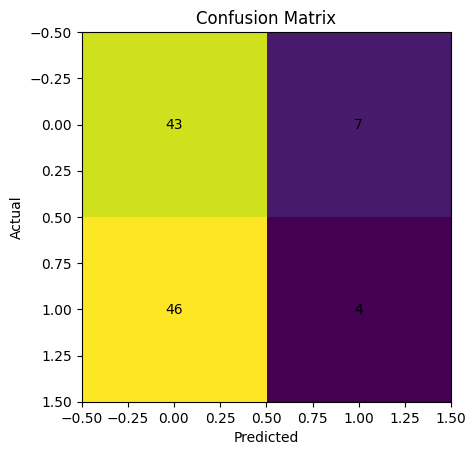

In [ ]:
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure()

plt.imshow(cm)

plt.title(
    "Confusion Matrix"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

for i in range(2):
    for j in range(2):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.show()

In [ ]:
results_df = pd.DataFrame({

    "actual": y_true,

    "predicted": y_pred,

    "llm_output": outputs

})

results_df.to_csv(
    "flan_100_sample_results.csv",
    index=False
)

print(" Results saved")

 Results saved


## **Final Results Comparision**

In [ ]:
df_train_results.columns

Index(['transaction type', 'merchant_category', 'transaction_status',
       'sender_age_group', 'receiver_age_group', 'sender_state', 'sender_bank',
       'receiver_bank', 'device_type', 'network_type', 'hour_of_day',
       'day_of_week', 'is_weekend', 'txn_day', 'txn_month', 'high_amount',
       'night_transaction', 'senior_sender', 'senior_high_amount',
       'amount_zscore', 'night_high_txn', 'bank_risk', 'network_risk',
       'amount_per_hour', 'is_p2p', 'is_senior', 'is_odd_hour',
       'large_p2p_transfer', 'p2p_odd_hour', 'senior_odd_hour', 'actual',
       'predicted', 'probability', 'prob_rf_calibrated', 'pred_rf_calibrated',
       'risk_bucket_calibrated', 'transaction_notes', 'clean_text',
       'text_pred', 'text_prob', 'mlp_probs'],
      dtype='object')

In [ ]:
df_test_results.columns

Index(['transaction type', 'merchant_category', 'transaction_status',
       'sender_age_group', 'receiver_age_group', 'sender_state', 'sender_bank',
       'receiver_bank', 'device_type', 'network_type', 'hour_of_day',
       'day_of_week', 'is_weekend', 'txn_day', 'txn_month', 'high_amount',
       'night_transaction', 'senior_sender', 'senior_high_amount',
       'amount_zscore', 'night_high_txn', 'bank_risk', 'network_risk',
       'amount_per_hour', 'is_p2p', 'is_senior', 'is_odd_hour',
       'large_p2p_transfer', 'p2p_odd_hour', 'senior_odd_hour', 'actual',
       'predicted', 'probability', 'risk_bucket', 'probability_calibrated',
       'risk_bucket_calibrated', 'prob_rf_calibrated', 'pred_rf_calibrated',
       'transaction_notes', 'clean_text', 'text_pred', 'text_prob',
       'hybrid_prob_alpha_0.03', 'hybrid_prob_alpha_0.05',
       'hybrid_prob_alpha_0.07', 'hybrid_prob_alpha_0.1',
       'risk_bucket_hybrid_0.03', 'risk_bucket_hybrid_0.05',
       'risk_bucket_hybrid_0.0

In [ ]:
# Save train and test dataframes to CSV

df_train_results.to_csv(
    "df_train_results1.csv",
    index=False
)

df_test_results.to_csv(
    "df_test_results1.csv",
    index=False
)

print("CSV files saved!")

CSV files saved!


## **15.Integrateing pretrained MLP**

In [ ]:
# import torch
# import torch.nn as nn

# class MultiModalMLP(nn.Module):

#     def __init__(self, tabular_dim, text_dim):

#         super().__init__()

#         # Tabular branch
#         self.tabular_net = nn.Sequential(

#             nn.Linear(tabular_dim, 128),
#             nn.ReLU(),
#             nn.BatchNorm1d(128),

#             nn.Linear(128, 64),
#             nn.ReLU()
#         )

#         # Text branch
#         self.text_net = nn.Sequential(

#             nn.Linear(text_dim, 256),
#             nn.ReLU(),

#             nn.Linear(256, 128),
#             nn.ReLU()
#         )

#         # Combined branch
#         self.combined_net = nn.Sequential(

#             nn.Linear(64 + 128, 128),
#             nn.ReLU(),

#             nn.Dropout(0.3),

#             nn.Linear(128, 64),
#             nn.ReLU(),

#             nn.Linear(64, 1)
#         )

#     def forward(self, tabular, text):

#         tab_out = self.tabular_net(tabular)

#         text_out = self.text_net(text)

#         combined = torch.cat(
#             (tab_out, text_out),
#             dim=1
#         )

#         output = self.combined_net(combined)

#         return output

In [ ]:
df_test = df_test_results.copy()

In [ ]:
text_col = "transaction_notes"
target_col = "actual"

# Columns to exclude from tabular input (updated with extra test columns)
exclude_cols = [
    text_col,
    target_col,
    "predicted",
    "probability",
    "prob_rf_calibrated",
    "pred_rf_calibrated",
    "risk_bucket_calibrated",
    "fraud_text_flag",
    "hybrid_prob_alpha_0.03",
    "hybrid_prob_alpha_0.05",
    "hybrid_prob_alpha_0.07",
    "hybrid_prob_alpha_0.1",
    "risk_bucket_hybrid_0.03",
    "risk_bucket_hybrid_0.05",
    "risk_bucket_hybrid_0.07",
    "risk_bucket_hybrid_0.1",
    "hybrid_probability",
    "risk_bucket_final",
    "hybrid_predicted",
    "rf_predicted_optimal",
    "risk_bucket"
]

# Tabular columns for model input
tabular_cols = [col for col in df_test.columns if col not in exclude_cols]
print("Tabular columns:", len(tabular_cols))
print(tabular_cols)

Tabular columns: 34
['transaction type', 'merchant_category', 'transaction_status', 'sender_age_group', 'receiver_age_group', 'sender_state', 'sender_bank', 'receiver_bank', 'device_type', 'network_type', 'hour_of_day', 'day_of_week', 'is_weekend', 'txn_day', 'txn_month', 'high_amount', 'night_transaction', 'senior_sender', 'senior_high_amount', 'amount_zscore', 'night_high_txn', 'bank_risk', 'network_risk', 'amount_per_hour', 'is_p2p', 'is_senior', 'is_odd_hour', 'large_p2p_transfer', 'p2p_odd_hour', 'senior_odd_hour', 'probability_calibrated', 'clean_text', 'text_pred', 'text_prob']


In [ ]:
# import torch

# tabular_data_test = df_test[tabular_cols].values.astype(float)

# X_tab_test = torch.tensor(
#     tabular_data_test,
#     dtype=torch.float32
# )

# print("Tabular shape:", X_tab_test.shape)

In [ ]:
# from sentence_transformers import SentenceTransformer

# text_model = SentenceTransformer(
#     "all-MiniLM-L6-v2"
# )

# texts_test = df_test[
#     "transaction_notes"
# ].astype(str).tolist()

# text_embeddings_test = text_model.encode(
#     texts_test,
#     batch_size=512,
#     show_progress_bar=True
# )

# X_text_test = torch.tensor(
#     text_embeddings_test,
#     dtype=torch.float32
# )

# print("Text shape:", X_text_test.shape)

In [ ]:
# device = torch.device(
#     "cuda" if torch.cuda.is_available() else "cpu"
# )
# mpdel_path = "/content/multimodal_mlp_model.pth"
# model = MultiModalMLP(
#     tabular_dim=X_tab_test.shape[1],
#     text_dim=X_text_test.shape[1]
# ).to(device)

# model.load_state_dict(
#     torch.load(
#         mpdel_path, # Corrected variable name from model_path to mpdel_path
#         map_location=device,
#         weights_only=False # Added weights_only=False to resolve the UnpicklingError
#     )
# )

# model.eval()

# print("MLP Loaded Successfully")

In [ ]:
# device = torch.device(
#     "cuda" if torch.cuda.is_available() else "cpu"
# )

# model = MultiModalMLP(
#     tabular_dim=X_tab_test.shape[1],
#     text_dim=X_text_test.shape[1]
# ).to(device)

# model.load_state_dict(
#     torch.load(
#         mpdel_path, # Changed from model_path to mpdel_path
#         map_location=device,
#         weights_only=False
#     )
# )

# model.eval()

# print("MLP model loaded successfully")

In [ ]:
# with torch.no_grad():

#     logits = model(
#         X_tab_test.to(device),
#         X_text_test.to(device)
#     )

#     probs = torch.sigmoid(logits)

# mlp_probs = probs.cpu().numpy().flatten()

# print("MLP probs shape:", mlp_probs.shape)

In [ ]:
# df_test_results["mlp_prob"] = mlp_probs

In [ ]:
# df_test_results.head()

In [ ]:
# mlp_alpha = 0.5

# df_test_results["hybrid_mlp_prob"] = (
#     df_test_results["hybrid_probability"] * (1 - mlp_alpha)
#     + df_test_results["mlp_prob"] * mlp_alpha
# ).clip(0, 1)

# print("New hybrid probabilities (incorporating MLP) created.")

In [ ]:
# df_test_results["risk_bucket_hybrid_mlp"] = pd.qcut(
#     df_test_results["hybrid_mlp_prob"],
#     q=4,
#     labels=[
#         "Low Risk",
#         "Medium Risk",
#         "High Risk",
#         "Critical Risk"
#     ]
# )

# print("New hybrid risk buckets (incorporating MLP) created.")

In [ ]:
# print("Hybrid Model with MLP Risk Bucket Analysis:")
# print(pd.crosstab(
#     df_test_results["risk_bucket_hybrid_mlp"],
#     df_test_results["actual"]
# ))

Evaluate Hybrid MLP Model

In [ ]:
# from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# # Binary classification (assuming actual is 0/1)
# y_true = df_test_results["actual"]
# y_pred = (df_test_results["hybrid_mlp_prob"] >= 0.5).astype(int)  # threshold 0.5

# print("Accuracy:", accuracy_score(y_true, y_pred))
# print("Precision:", precision_score(y_true, y_pred))
# print("Recall:", recall_score(y_true, y_pred))
# print("F1-score:", f1_score(y_true, y_pred))
# print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))

In [ ]:
# import seaborn as sns
# import matplotlib.pyplot as plt

# sns.countplot(
#     x="risk_bucket_hybrid_mlp",
#     hue="actual",
#     data=df_test_results,
#     palette="Set2"
# )
# plt.title("Hybrid MLP Risk Bucket vs Actual Fraud")
# plt.show()

In [ ]:
# df_test_results.to_csv("df_test_results_hybrid_mlp.csv", index=False)

In [ ]:
# from sklearn.metrics import classification_report, confusion_matrix

# # Binary prediction using 0.5 threshold
# y_true = df_test_results["actual"]
# y_pred_hybrid_mlp = (df_test_results["hybrid_mlp_prob"] >= 0.5).astype(int)

# # Classification report
# report_hybrid_mlp = classification_report(y_true, y_pred_hybrid_mlp, output_dict=True)
# print("Classification Report for RF+Keywords+MLP Hybrid:")
# print(classification_report(y_true, y_pred_hybrid_mlp))

In [ ]:
# # RF only
# y_pred_rf = df_test_results["predicted"]
# report_rf = classification_report(y_true, y_pred_rf, output_dict=True)

# # RF + Keywords
# y_pred_rf_keywords = df_test_results["pred_rf_calibrated"]
# report_rf_keywords = classification_report(y_true, y_pred_rf_keywords, output_dict=True)

In [ ]:
# y_true = df_test_results["actual"]

# # RF Only
# y_pred_rf = df_test_results["rf_predicted_optimal"]
# report_rf = classification_report(y_true, y_pred_rf, output_dict=True)

# # RF + Keywords (Hybrid before adding MLP)
# y_pred_hybrid = df_test_results["hybrid_predicted"]
# report_hybrid = classification_report(y_true, y_pred_hybrid, output_dict=True)

# # RF + Keywords + MLP (New hybrid)
# y_pred_hybrid_mlp = (df_test_results["hybrid_mlp_prob"] >= 0.5).astype(int)
# report_hybrid_mlp = classification_report(y_true, y_pred_hybrid_mlp, output_dict=True)

# print("===== RANDOM FOREST ONLY =====")
# print(classification_report(y_true, y_pred_rf))

# print("\n===== HYBRID MODEL (RF + Keywords) =====")
# print(classification_report(y_true, y_pred_hybrid))

# print("\n===== HYBRID MODEL (RF + Keywords + MLP) =====")
# print(classification_report(y_true, y_pred_hybrid_mlp))

In [ ]:
# import pandas as pd
# from sklearn.metrics import classification_report

# y_true = df_test_results["actual"]

# # RF Only
# y_pred_rf = df_test_results["rf_predicted_optimal"]
# report_rf = classification_report(y_true, y_pred_rf, output_dict=True)

# # RF + Keywords
# y_pred_hybrid = df_test_results["hybrid_predicted"]
# report_hybrid = classification_report(y_true, y_pred_hybrid, output_dict=True)

# # RF + Keywords + MLP
# y_pred_hybrid_mlp = (df_test_results["hybrid_mlp_prob"] >= 0.5).astype(int)
# report_hybrid_mlp = classification_report(y_true, y_pred_hybrid_mlp, output_dict=True)

# # Safe getter for f1-score
# def safe_get_f1(report, cls):
#     cls_key = str(cls)  # class labels are strings in the dict
#     return report[cls_key]['f1-score']  # use 'f1-score', not 'f1'

# # Comparison table
# comparison_df = pd.DataFrame({
#     "RF Only": [
#         safe_get_f1(report_rf, 0),
#         safe_get_f1(report_rf, 1),
#         report_rf['accuracy']
#     ],
#     "RF + Keywords": [
#         safe_get_f1(report_hybrid, 0),
#         safe_get_f1(report_hybrid, 1),
#         report_hybrid['accuracy']
#     ],
#     "RF + Keywords + MLP": [
#         safe_get_f1(report_hybrid_mlp, 0),
#         safe_get_f1(report_hybrid_mlp, 1),
#         report_hybrid_mlp['accuracy']
#     ]
# }, index=["F1 (Non-Fraud)", "F1 (Fraud)", "Accuracy"])

# print("\n===== Model Comparison Table =====")
# print(comparison_df)

In [ ]:
# for alpha in [0.1, 0.2, 0.3, 0.4, 0.5]:
#     df_test_results["hybrid_mlp_prob"] = (
#         df_test_results["hybrid_probability"] * (1 - alpha)
#         + df_test_results["mlp_prob"] * alpha
#     )
#     y_pred = (df_test_results["hybrid_mlp_prob"] >= 0.5).astype(int)
#     f1_fraud = classification_report(y_true, y_pred, output_dict=True)['1']['f1-score']
#     print(f"alpha={alpha}, F1 (Fraud) = {f1_fraud:.4f}")

In [ ]:
# import numpy as np
# from sklearn.metrics import f1_score

# best_thresh = 0
# best_f1 = 0
# probs = df_test_results["hybrid_mlp_prob"].values

# for thresh in np.arange(0.1, 0.9, 0.01):
#     y_pred = (probs >= thresh).astype(int)
#     f1 = f1_score(y_true, y_pred)
#     if f1 > best_f1:
#         best_f1 = f1
#         best_thresh = thresh

# print("Best threshold:", best_thresh, "Best F1 (Fraud):", best_f1)

In [ ]:
# y_pred_mlp = (df_test_results["mlp_prob"] >= 0.5).astype(int)
# print(classification_report(y_true, y_pred_mlp))